<h1>Closed - Set Mobile ViT + BioClinicalBERT (gated fusion)</h1>

In [1]:
# ============================================================
# PAD-UFES ONLY CLOSED-SET BASELINE
# MobileViT + BioClinicalBERT text fusion
# 3 text experiments + WeightedRandomSampler + extended metrics
# Confusion matrix, ROC curves, GradCAM++, and t-SNE outputs
# ============================================================

import os
import gc
import json
import random
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
from transformers import AutoModel, AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

from tqdm import tqdm

import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PADUFES_FILE = Path("D:/Deep Learning/metadata.csv")
PADUFES_IMAGE_DIR = Path("D:/Deep Learning/images")
RESULT_DIR = Path(r"D:\Deep Learning\output\gated_mobilevit")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_NAME = "gated_mobile_vit"

IMAGE_MODEL_NAME = "mobilevit_s.cvnets_in1k"
TEXT_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

BATCH_SIZE = 32
NUM_WORKERS = 0

EPOCHS = 50
PATIENCE = 5

LR = 1e-4
WEIGHT_DECAY = 1e-4

MAX_TEXT_LEN = 96

BALANCE_BETA = 0.99

USE_SOFT_WEIGHTED_SAMPLER = True
USE_WEIGHTED_LOSS = True

FREEZE_BACKBONES = False

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]

# Saves plots by default. Set to True when running in a notebook and you also want them displayed inline.
SHOW_PLOTS = False

N_GRADCAM_EXAMPLES = 6

KNOWN_CLASSES = ["AK", "BCC", "MEL", "NEV", "SCC", "SK"]

LABEL_TO_ID = {label: idx for idx, label in enumerate(KNOWN_CLASSES)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}
NUM_CLASSES = len(KNOWN_CLASSES)

print("Device:", DEVICE)
print("Freeze backbones:", FREEZE_BACKBONES)
print("Text experiments:", TEXT_EXPERIMENTS)


# ============================================================
# LABEL HARMONIZATION
# ============================================================

LABEL_MAP = {
    "ACK": "AK",
    "AK": "AK",
    "BCC": "BCC",
    "MEL": "MEL",
    "NEV": "NEV",
    "NV": "NEV",
    "SCC": "SCC",
    "SEK": "SK",
    "SK": "SK",
    "BKL": "SK",
}


def harmonize_label(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()
    x = x.replace("-", "_").replace("/", "_").replace(" ", "_")

    return LABEL_MAP.get(x, x)


# ============================================================
# METADATA TEXTUALIZATION
# ============================================================

def is_missing(x):
    if pd.isna(x):
        return True

    x = str(x).strip().lower()

    return x in [
        "",
        "nan",
        "none",
        "null",
        "unknown",
        "unspecified",
        "na",
        "n/a",
    ]


def clean_text(x):
    if is_missing(x):
        return "unknown"

    return str(x).strip()


def clean_bool(x):
    if is_missing(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["true", "1", "yes", "y"]:
        return "yes"

    if x in ["false", "0", "no", "n"]:
        return "no"

    return "unknown"


def clean_numeric(x, min_val=None, max_val=None):
    if is_missing(x):
        return "unknown"

    try:
        v = float(x)

        if min_val is not None and v < min_val:
            return "unknown"

        if max_val is not None and v > max_val:
            return "unknown"

        if v.is_integer():
            return str(int(v))

        return f"{v:.1f}"

    except Exception:
        return "unknown"


def standardize_location(x):
    if is_missing(x):
        return "unknown"

    x = str(x).strip().lower().replace("_", " ").replace("-", " ")

    mapping = {
        "face": "face",
        "scalp": "scalp",
        "ear": "ear",
        "neck": "neck",
        "head neck": "head or neck",
        "head/neck": "head or neck",
        "chest": "chest",
        "abdomen": "abdomen",
        "back": "back",
        "torso": "torso",
        "trunk": "torso",
        "arm": "upper limb",
        "forearm": "upper limb",
        "hand": "hand",
        "leg": "lower limb",
        "thigh": "lower limb",
        "foot": "foot",
    }

    return mapping.get(x, x)


def build_metadata_text(row):
    age = clean_numeric(
        row.get("age", np.nan),
        min_val=0,
        max_val=120
    )

    gender = clean_text(row.get("gender", np.nan)).lower()

    if gender in ["male", "m", "man"]:
        sex = "male"

    elif gender in ["female", "f", "woman"]:
        sex = "female"

    else:
        sex = "unknown"

    location = standardize_location(
        row.get("region", np.nan)
    )

    d1 = clean_numeric(
        row.get("diameter_1", np.nan),
        min_val=0,
        max_val=300
    )

    d2 = clean_numeric(
        row.get("diameter_2", np.nan),
        min_val=0,
        max_val=300
    )

    if d1 != "unknown" and d2 != "unknown":
        diameter = f"{d1} by {d2} mm"

    elif d1 != "unknown":
        diameter = f"{d1} mm"

    elif d2 != "unknown":
        diameter = f"{d2} mm"

    else:
        diameter = "unknown"

    meta = {
        "age": age,
        "sex": sex,
        "location": location,
        "diameter": diameter,
        "fitzpatrick": clean_numeric(row.get("fitspatrick", np.nan), min_val=1, max_val=6),

        "itch": clean_bool(row.get("itch", np.nan)),
        "grew": clean_bool(row.get("grew", np.nan)),
        "hurt": clean_bool(row.get("hurt", np.nan)),
        "changed": clean_bool(row.get("changed", np.nan)),
        "bleed": clean_bool(row.get("bleed", np.nan)),
        "elevation": clean_bool(row.get("elevation", np.nan)),

        "smoking": clean_bool(row.get("smoke", np.nan)),
        "alcohol": clean_bool(row.get("drink", np.nan)),
        "pesticide_exposure": clean_bool(row.get("pesticide", np.nan)),

        "personal_skin_cancer_history": clean_bool(row.get("skin_cancer_history", np.nan)),
        "general_cancer_history": clean_bool(row.get("cancer_history", np.nan)),
    }

    age_text = "an unknown age" if meta["age"] == "unknown" else f"{meta['age']} years old"
    sex_text = "unspecified biological sex" if meta["sex"] == "unknown" else meta["sex"]
    loc_text = "an unspecified anatomical location" if meta["location"] == "unknown" else meta["location"]

    text_core = (
        f"A clinical image of a skin lesion located on {loc_text} "
        f"from a patient who is {age_text} with {sex_text}."
    )

    text_full = (
        text_core + " "
        f"Diameter: {meta['diameter']}. "
        f"Fitzpatrick skin type: {meta['fitzpatrick']}. "
        f"Symptoms include itching: {meta['itch']}, growth: {meta['grew']}, pain: {meta['hurt']}, "
        f"change: {meta['changed']}, bleeding: {meta['bleed']}, elevation: {meta['elevation']}. "
        f"Smoking: {meta['smoking']}. Alcohol: {meta['alcohol']}. "
        f"Pesticide exposure: {meta['pesticide_exposure']}. "
        f"Personal skin cancer history: {meta['personal_skin_cancer_history']}. "
        f"General cancer history: {meta['general_cancer_history']}."
    )

    text_missing_explicit = text_core + " " + "; ".join(
        [f"{k}: {v}" for k, v in sorted(meta.items())]
    )

    return text_core, text_full, text_missing_explicit


# ============================================================
# LOAD PAD-UFES
# ============================================================

df = pd.read_csv(PADUFES_FILE)

df["label_harmonized"] = df["diagnostic"].apply(harmonize_label)

df = df[df["label_harmonized"].isin(KNOWN_CLASSES)].copy()

df["label_id"] = df["label_harmonized"].map(LABEL_TO_ID)

df["image_file"] = df["img_id"].astype(str)

texts = df.apply(build_metadata_text, axis=1)

df["text_core"] = [x[0] for x in texts]
df["text_full"] = [x[1] for x in texts]
df["text_missing_explicit"] = [x[2] for x in texts]

print("\nClass distribution:")
print(df["label_harmonized"].value_counts().sort_index())


# ============================================================
# IMAGE PATHS
# ============================================================

def resolve_padufes_image_path(image_file):
    candidates = [
        PADUFES_IMAGE_DIR / image_file,
        PADUFES_IMAGE_DIR / f"{image_file}.jpg",
        PADUFES_IMAGE_DIR / f"{image_file}.jpeg",
        PADUFES_IMAGE_DIR / f"{image_file}.png",
    ]

    for p in candidates:
        if p.exists():
            return str(p)

    return None


df["image_path"] = df["image_file"].apply(resolve_padufes_image_path)

missing = df["image_path"].isna().sum()

print("\nMissing images:", missing)

df = df[df["image_path"].notna()].reset_index(drop=True)


# ============================================================
# SPLIT: TRAIN / VAL / TEST = 70 / 15 / 15
# Same split is reused for all 3 text experiments.
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain class counts:")
print(train_df["label_harmonized"].value_counts().sort_index())

print("\nVal class counts:")
print(val_df["label_harmonized"].value_counts().sort_index())

print("\nTest class counts:")
print(test_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# TRANSFORMS + TOKENIZER
# ============================================================

from torchvision import transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),      
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(
        brightness=0.2,                       
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),         
    transforms.GaussianBlur(kernel_size=3,     
                            sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.1,            
                             scale=(0.02, 0.1))
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)


# ============================================================
# DATASET
# ============================================================

class PadUfesClosedSetDataset(Dataset):

    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }


# ============================================================
# WEIGHTED RANDOM SAMPLER
# ============================================================

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(train_df, beta=0.9):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights


# ============================================================
# MODEL
# ============================================================

class MobileViTAdapter(nn.Module):

    def __init__(self, model_name):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True
        )

        self.last_feature_map = None

    def forward(self, x):
        feats = self.backbone(x)

        last = feats[-1]

        # Needed for the built-in GradCAM++ implementation below.
        self.last_feature_map = last
        if last.requires_grad:
            last.retain_grad()

        B, C, H, W = last.shape

        spatial = (
            last.reshape(B, C, H * W)
            .permute(0, 2, 1)
            .contiguous()
        )

        global_token = (
            last.mean(dim=(2, 3))
            .unsqueeze(1)
        )

        return torch.cat(
            [global_token, spatial],
            dim=1
        )


class MobileViTTextFusionClosedSet(nn.Module):

    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,   # kept only so old calls do not break
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = MobileViTAdapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Sigmoid()
        )

        self.norm = nn.LayerNorm(fusion_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        return_features=False
    ):
        image_tokens = self.image_encoder(pixel_values)
        image_feat = image_tokens[:, 0, :]

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_out.last_hidden_state[:, 0, :]

        image_feat = self.image_proj(image_feat)
        text_feat = self.text_proj(text_feat)

        combined = torch.cat([image_feat, text_feat], dim=1)

        gate = self.gate(combined)

        fused_cls = gate * image_feat + (1.0 - gate) * text_feat
        fused_cls = self.norm(fused_cls)

        logits = self.classifier(fused_cls)

        if return_features:
            return logits, fused_cls

        return logits


# ============================================================
# UTILS
# ============================================================

def batch_to_device(batch):
    return {
        k: v.to(DEVICE)
        for k, v in batch.items()
        if torch.is_tensor(v)
    }


def maybe_show_or_close():
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()


def save_json(obj, path):
    cleaned = {}
    for k, v in obj.items():
        if isinstance(v, (np.floating, np.integer)):
            cleaned[k] = v.item()
        elif isinstance(v, float) and np.isnan(v):
            cleaned[k] = None
        else:
            cleaned[k] = v

    with open(path, "w", encoding="utf-8") as f:
        json.dump(cleaned, f, indent=2)


def tensor_to_display_image(tensor):
    # tensor shape: [3, H, W], normalized with ImageNet statistics
    x = tensor.detach().cpu().clone()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    x = x * std + mean
    x = x.clamp(0, 1)

    return x.permute(1, 2, 0).numpy()


# ============================================================
# METRICS
# ============================================================

def compute_multiclass_auc(y_true, y_prob):
    metrics = {}

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(NUM_CLASSES)),
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        metrics["macro_auc_ovr"] = np.nan

    try:
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(NUM_CLASSES)),
            multi_class="ovr",
            average="weighted"
        )
    except Exception:
        metrics["weighted_auc_ovr"] = np.nan

    y_bin = label_binarize(
        y_true,
        classes=list(range(NUM_CLASSES))
    )

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        try:
            if len(np.unique(y_bin[:, class_idx])) < 2:
                metrics[f"auc_{class_name}"] = np.nan
            else:
                metrics[f"auc_{class_name}"] = roc_auc_score(
                    y_bin[:, class_idx],
                    y_prob[:, class_idx]
                )
        except Exception:
            metrics[f"auc_{class_name}"] = np.nan

    return metrics


def compute_metrics(y_true, y_pred, y_prob, avg_loss):
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),

        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),

        "weighted_precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "weighted_recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

    metrics.update(
        compute_multiclass_auc(y_true, y_prob)
    )

    # Alias for the main AUC score.
    metrics["auc"] = metrics["macro_auc_ovr"]

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, name="EVAL", print_report=False, output_dir=None):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = batch_to_device(batch)

        logits = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        loss = criterion(
            logits,
            batch["label"]
        )

        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(
            batch["label"].detach().cpu().numpy()
        )

        all_pred.extend(
            preds.detach().cpu().numpy()
        )

        all_prob.append(
            probs.detach().cpu().numpy()
        )

    avg_loss = total_loss / max(len(loader), 1)

    y_true = np.asarray(all_true)
    y_pred = np.asarray(all_pred)
    y_prob = np.concatenate(all_prob, axis=0)

    metrics = compute_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        avg_loss=avg_loss
    )

    if print_report:
        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)
        print(f"Loss: {metrics['loss']:.4f}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision macro: {metrics['macro_precision']:.4f}")
        print(f"Recall macro: {metrics['macro_recall']:.4f}")
        print(f"F1 macro: {metrics['macro_f1']:.4f}")
        print(f"AUC macro OVR: {metrics['macro_auc_ovr']:.4f}")
        print(f"AUC weighted OVR: {metrics['weighted_auc_ovr']:.4f}")

        print("\nClassification report:")
        print(
            classification_report(
                y_true,
                y_pred,
                labels=list(range(NUM_CLASSES)),
                target_names=KNOWN_CLASSES,
                zero_division=0,
                digits=4
            )
        )

        if output_dir is not None:
            report_dict = classification_report(
                y_true,
                y_pred,
                labels=list(range(NUM_CLASSES)),
                target_names=KNOWN_CLASSES,
                zero_division=0,
                digits=4,
                output_dict=True
            )

            pd.DataFrame(report_dict).transpose().round(4).to_csv(
                output_dir / f"{name.lower().replace(' ', '_')}_classification_report.csv"
            )

            pd.DataFrame({
                "y_true": y_true,
                "y_pred": y_pred,
                **{
                    f"prob_{KNOWN_CLASSES[i]}": y_prob[:, i]
                    for i in range(NUM_CLASSES)
                }
            }).to_csv(
                output_dir / f"{name.lower().replace(' ', '_')}_predictions.csv",
                index=False
            )

    return metrics, y_true, y_pred, y_prob


# ============================================================
# PLOTS
# ============================================================

def plot_normalized_confusion_matrix(y_true, y_pred, output_path, title):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=KNOWN_CLASSES
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".4f",
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    maybe_show_or_close()


def plot_multiclass_roc(y_true, y_prob, output_path, title):
    y_bin = label_binarize(
        y_true,
        classes=list(range(NUM_CLASSES))
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        # ROC is undefined if this class has no positive or no negative samples.
        if len(np.unique(y_bin[:, class_idx])) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            y_bin[:, class_idx],
            y_prob[:, class_idx]
        )

        class_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_name} AUC={class_auc:.4f}"
        )

    try:
        fpr_micro, tpr_micro, _ = roc_curve(
            y_bin.ravel(),
            y_prob.ravel()
        )

        micro_auc = auc(fpr_micro, tpr_micro)

        ax.plot(
            fpr_micro,
            tpr_micro,
            linestyle="--",
            linewidth=2,
            label=f"micro-average AUC={micro_auc:.4f}"
        )
    except Exception:
        pass

    ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=650, bbox_inches="tight")
    maybe_show_or_close()


# ============================================================
# GRADCAM++
# ============================================================

def compute_gradcampp_from_feature_map(activations, gradients, eps=1e-8):
    """
    activations: [C, H, W]
    gradients:   [C, H, W]
    """
    grad_2 = gradients.pow(2)
    grad_3 = gradients.pow(3)

    spatial_sum = torch.sum(
        activations * grad_3,
        dim=(1, 2),
        keepdim=True
    )

    alpha = grad_2 / (2.0 * grad_2 + spatial_sum + eps)
    alpha = torch.where(
        torch.isfinite(alpha),
        alpha,
        torch.zeros_like(alpha)
    )

    weights = torch.sum(
        alpha * F.relu(gradients),
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * activations,
        dim=0
    )

    cam = F.relu(cam)

    cam_min = cam.min()
    cam_max = cam.max()

    if (cam_max - cam_min) > eps:
        cam = (cam - cam_min) / (cam_max - cam_min + eps)
    else:
        cam = torch.zeros_like(cam)

    return cam


def generate_gradcampp_examples(model, dataset, output_dir, n_examples=6):
    output_dir.mkdir(exist_ok=True, parents=True)

    model.eval()

    # Pick diverse examples: first available test image from each class.
    selected_indices = []
    labels = dataset.df["label_id"].to_numpy()

    for class_idx in range(NUM_CLASSES):
        idxs = np.where(labels == class_idx)[0]
        if len(idxs) > 0:
            selected_indices.append(int(idxs[0]))

    selected_indices = selected_indices[:n_examples]

    saved = 0

    for dataset_idx in selected_indices:
        sample = dataset[dataset_idx]

        pixel_values = sample["pixel_values"].unsqueeze(0).to(DEVICE)
        pixel_values.requires_grad_(True)

        input_ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)
        true_label = int(sample["label"].item())

        model.zero_grad(set_to_none=True)

        logits = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(logits, dim=1)
        pred_label = int(torch.argmax(probs, dim=1).item())

        target_score = logits[0, pred_label]
        target_score.backward(retain_graph=True)

        feature_map = model.image_encoder.last_feature_map

        if feature_map is None or feature_map.grad is None:
            print("Skipping GradCAM++ example because gradients were unavailable.")
            continue

        activations = feature_map.detach()[0]
        gradients = feature_map.grad.detach()[0]

        cam = compute_gradcampp_from_feature_map(
            activations=activations,
            gradients=gradients
        )

        cam = F.interpolate(
            cam[None, None, :, :],
            size=pixel_values.shape[-2:],
            mode="bilinear",
            align_corners=False
        )[0, 0]

        cam_np = cam.detach().cpu().numpy()
        image_np = tensor_to_display_image(sample["pixel_values"])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np)
        plt.imshow(cam_np, cmap="jet", alpha=0.45)
        plt.axis("off")

        plt.title(
            f"True: {ID_TO_LABEL[true_label]} | "
            f"Pred: {ID_TO_LABEL[pred_label]} | "
            f"P={probs[0, pred_label].item():.4f}"
        )

        out_path = output_dir / (
            f"gradcampp_{saved:02d}_"
            f"true_{ID_TO_LABEL[true_label]}_"
            f"pred_{ID_TO_LABEL[pred_label]}.png"
        )

        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        maybe_show_or_close()

        saved += 1

    print(f"Saved {saved} GradCAM++ examples to: {output_dir}")


# ============================================================
# T-SNE
# ============================================================

@torch.no_grad()
def extract_fused_features(model, loader):
    model.eval()

    all_features = []
    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc="Extracting fused features", leave=False):
        batch = batch_to_device(batch)

        logits, fused_features = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            return_features=True
        )

        preds = logits.argmax(dim=1)

        all_features.append(
            fused_features.detach().cpu().numpy()
        )

        all_true.extend(
            batch["label"].detach().cpu().numpy()
        )

        all_pred.extend(
            preds.detach().cpu().numpy()
        )

    return (
        np.concatenate(all_features, axis=0),
        np.asarray(all_true),
        np.asarray(all_pred)
    )


def plot_tsne(model, loader, output_dir, title):
    features, y_true, y_pred = extract_fused_features(
        model,
        loader
    )

    n_samples = features.shape[0]

    if n_samples < 3:
        print("Skipping t-SNE because there are fewer than 3 samples.")
        return

    perplexity = min(30, max(2, (n_samples - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED
    )

    emb = tsne.fit_transform(features)

    tsne_df = pd.DataFrame({
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "true_label_id": y_true,
        "true_label": [ID_TO_LABEL[int(x)] for x in y_true],
        "pred_label_id": y_pred,
        "pred_label": [ID_TO_LABEL[int(x)] for x in y_pred],
    })

    tsne_df.to_csv(
        output_dir / "test_tsne_coordinates.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        mask = y_true == class_idx

        if mask.sum() == 0:
            continue

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            s=35,
            alpha=0.8,
            label=class_name
        )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(title="True class", fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        output_dir / "test_tsne_true_labels.png",
        dpi=300,
        bbox_inches="tight"
    )
    maybe_show_or_close()

    fig, ax = plt.subplots(figsize=(8, 7))

    correct = y_true == y_pred

    ax.scatter(
        emb[correct, 0],
        emb[correct, 1],
        s=35,
        alpha=0.8,
        label="correct"
    )

    ax.scatter(
        emb[~correct, 0],
        emb[~correct, 1],
        s=35,
        alpha=0.8,
        label="incorrect"
    )

    ax.set_title(title + " correctness")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        output_dir / "test_tsne_correct_vs_incorrect.png",
        dpi=300,
        bbox_inches="tight"
    )
    maybe_show_or_close()


# ============================================================
# EXPERIMENT RUNNER
# ============================================================

def build_loaders_for_text_col(text_col):
    train_ds = PadUfesClosedSetDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col
    )

    val_ds = PadUfesClosedSetDataset(
        val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    test_ds = PadUfesClosedSetDataset(
        test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    train_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    train_eval_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    return train_loader, train_eval_loader, val_loader, test_loader, test_ds


train_loader, train_eval_loader, val_loader, test_loader, test_ds = build_loaders_for_text_col(TEXT_EXPERIMENTS[0])

from collections import Counter

def print_loader_dataset_counts(name, loader):
    # Fast: read labels directly from the dataset dataframe.
    # This avoids loading/augmenting every image just to count labels.
    labels = loader.dataset.df["label_id"].astype(int).to_numpy()

    counts = Counter(labels)
    total = sum(counts.values())

    print(f"\n=== {name} Set Class Distribution ===")
    for cls_id in range(NUM_CLASSES):
        count = counts.get(cls_id, 0)
        pct = 100 * count / total if total > 0 else 0
        bar = "█" * int(40 * count / total) if total > 0 else ""
        print(f"{ID_TO_LABEL[cls_id]:>3} / Class {cls_id}: {count:>5} ({pct:>5.1f}%)  {bar}")

    if counts:
        max_count = max(counts.values())
        min_count = min(counts.values())
        print(f"\nTotal samples   : {total}")
        print(f"Num classes     : {len(counts)}")
        print(f"Imbalance ratio : {max_count / min_count:.1f}x")


print_loader_dataset_counts("Training", train_loader)
print_loader_dataset_counts("Validation", val_loader)
print_loader_dataset_counts("Test", test_loader)


def run_single_experiment(text_col):
    print("\n" + "#" * 80)
    print(f"STARTING EXPERIMENT: {text_col}")
    print("#" * 80)


    experiment_dir = RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)
    
    best_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    final_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_final.pt"
    (
        train_loader,
        train_eval_loader,
        val_loader,
        test_loader,
        test_ds
    ) = build_loaders_for_text_col(text_col)

    model = MobileViTTextFusionClosedSet(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    # WeightedRandomSampler already balances the batches.
    # Avoid using class-weighted CE simultaneously unless you intentionally want stronger minority weighting.
    if USE_WEIGHTED_LOSS:
        loss_weights = get_loss_weights_from_train_df(
            train_df,
            beta=BALANCE_BETA,
            device=DEVICE
        )
    
        criterion = nn.CrossEntropyLoss(
            weight=loss_weights
        )
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=3,
        factor=0.5
    )

    best_val_f1 = -np.inf
    early_count = 0

    best_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    final_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_final.pt"

    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()

        running_loss = 0.0

        pbar = tqdm(
            train_loader,
            desc=f"{text_col} | Epoch {epoch}/{EPOCHS}"
        )

        for batch in pbar:
            batch = batch_to_device(batch)

            optimizer.zero_grad(set_to_none=True)

            logits = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            loss = criterion(
                logits,
                batch["label"]
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pbar.set_postfix(
                {
                    "loss": f"{running_loss / (pbar.n + 1):.4f}"
                }
            )

        train_metrics, _, _, _ = evaluate(
            model,
            train_eval_loader,
            criterion,
            name=f"{text_col} TRAIN EPOCH {epoch}",
            print_report=False
        )

        val_metrics, _, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            name=f"{text_col} VAL EPOCH {epoch}",
            print_report=False
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"\n{text_col} | Epoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Train Loss={train_metrics['loss']:.4f}, "
            f"Train Acc={train_metrics['accuracy']:.4f}, "
            f"Train Macro-F1={train_metrics['macro_f1']:.4f}, "
            f"Train AUC={train_metrics['auc']:.4f} | "
            f"Val Loss={val_metrics['loss']:.4f}, "
            f"Val Acc={val_metrics['accuracy']:.4f}, "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f}, "
            f"Val AUC={val_metrics['auc']:.4f}"
        )

        history_row = {
            "epoch": epoch,
            "lr": current_lr,
        }

        for k, v in train_metrics.items():
            history_row[f"train_{k}"] = v

        for k, v in val_metrics.items():
            history_row[f"val_{k}"] = v

        history.append(history_row)

        pd.DataFrame(history).to_csv(
            experiment_dir / f"padufes_closed_set_{text_col}_history.csv",
            index=False
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )


            print(
                f"Saved best model with val Macro-F1: {best_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= PATIENCE:
                print("Early stopping.")
                break

    # ========================================================
    # FINAL TEST EVALUATION
    # ========================================================

    model.load_state_dict(
        torch.load(best_model_path, map_location=DEVICE)
    )

    test_metrics, y_true, y_pred, y_prob = evaluate(
        model,
        test_loader,
        criterion,
        name=f"{text_col} FINAL TEST",
        print_report=True,
        output_dir=experiment_dir
    )

    torch.save(
        model.state_dict(),
        final_model_path
    )

    save_json(
        {
            "text_col": text_col,
            "best_val_macro_f1": best_val_f1,
            **test_metrics,
        },
        experiment_dir / f"padufes_closed_set_{text_col}_test_metrics.json"
    )

    plot_normalized_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        output_path=experiment_dir / "normalized_confusion_matrix_mobileVitCrossAttention.png",
        title=f"{text_col} normalized confusion matrix"
    )

    plot_multiclass_roc(
        y_true=y_true,
        y_prob=y_prob,
        output_path=experiment_dir / "multiclass_roc_curve_mobileVitCrossAttention.png",
        title=f"{text_col} multiclass ROC curve"
    )

    generate_gradcampp_examples(
        model=model,
        dataset=test_ds,
        output_dir=experiment_dir / "gradcampp_mobileVitCrossAttention",
        n_examples=N_GRADCAM_EXAMPLES
    )

    plot_tsne(
        model=model,
        loader=test_loader,
        output_dir=experiment_dir,
        title=f"{text_col} test fused-feature t-SNE"
    )

    print("\nFinished experiment:", text_col)
    print("Best validation Macro-F1:", best_val_f1)
    print("Final test metrics:", test_metrics)

    result_row = {
        "text_col": text_col,
        "best_val_macro_f1": best_val_f1,
        **test_metrics
    }

    # Clear memory before next experiment.
    del model
    del optimizer
    del scheduler
    del train_loader
    del train_eval_loader
    del val_loader
    del test_loader
    del test_ds

    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return result_row

Device: cuda
Freeze backbones: False
Text experiments: ['text_full', 'text_core', 'text_missing_explicit']

Class distribution:
label_harmonized
AK     730
BCC    845
MEL     52
NEV    244
SCC    192
SK     235
Name: count, dtype: int64

Missing images: 0

Split sizes:
Train: (1608, 33)
Val: (345, 33)
Test: (345, 33)

Train class counts:
label_harmonized
AK     511
BCC    591
MEL     36
NEV    171
SCC    134
SK     165
Name: count, dtype: int64

Val class counts:
label_harmonized
AK     109
BCC    127
MEL      8
NEV     37
SCC     29
SK      35
Name: count, dtype: int64

Test class counts:
label_harmonized
AK     110
BCC    127
MEL      8
NEV     36
SCC     29
SK      35
Name: count, dtype: int64



=== Training Set Class Distribution ===
 AK / Class 0:   511 ( 31.8%)  ████████████
BCC / Class 1:   591 ( 36.8%)  ██████████████
MEL / Class 2:    36 (  2.2%)  
NEV / Class 3:   171 ( 10.6%)  ████
SCC / Class 4:   134 (  8.3%)  ███
 SK / Class 5:   165 ( 10.3%)  ████

Total samples   : 1608
Num classes     : 6
Imbalance ratio : 16.4x

=== Validation Set Class Distribution ===
 AK / Class 0:   109 ( 31.6%)  ████████████
BCC / Class 1:   127 ( 36.8%)  ██████████████
MEL / Class 2:     8 (  2.3%)  
NEV / Class 3:    37 ( 10.7%)  ████
SCC / Class 4:    29 (  8.4%)  ███
 SK / Class 5:    35 ( 10.1%)  ████

Total samples   : 345
Num classes     : 6
Imbalance ratio : 15.9x

=== Test Set Class Distribution ===
 AK / Class 0:   110 ( 31.9%)  ████████████
BCC / Class 1:   127 ( 36.8%)  ██████████████
MEL / Class 2:     8 (  2.3%)  
NEV / Class 3:    36 ( 10.4%)  ████
SCC / Class 4:    29 (  8.4%)  ███
 SK / Class 5:    35 ( 10.1%)  ████

Total samples   : 345
Num classes     : 6
Imbalance rati

In [2]:
# ============================================================
# RUN ALL THREE EXPERIMENTS
# ============================================================

all_results = []

for text_col in TEXT_EXPERIMENTS:
    result_row = run_single_experiment(text_col)
    all_results.append(result_row)

summary_df = pd.DataFrame(all_results)
summary_path = RESULT_DIR / "padufes_closed_set_all_text_experiments_summary_mobileVitCrossAttention.csv"
summary_df.round(4).to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 80)
print(summary_df.round(4))
print("\nSaved summary to:", summary_path)


################################################################################
STARTING EXPERIMENT: text_full
################################################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Class weights for loss:
  AK: 0.6627
  BCC: 0.6605
  MEL: 2.1700
  NEV: 0.8027
  SCC: 0.8903
  SK: 0.8138


text_full | Epoch 1/50: 100%|██████████| 51/51 [03:13<00:00,  3.79s/it, loss=1.4247]
                                                                                   

...


text_missing_explicit | Epoch 17 Summary | LR=5.00e-05 | Train Loss=0.2872, Train Acc=0.8986, Train Macro-F1=0.8714, Train AUC=0.9881 | Val Loss=0.6832, Val Acc=0.7478, Val Macro-F1=0.6887, Val AUC=0.9429


text_missing_explicit | Epoch 18/50: 100%|██████████| 51/51 [00:53<00:00,  1.05s/it, loss=0.2986]
                                                                                                


text_missing_explicit | Epoch 18 Summary | LR=5.00e-05 | Train Loss=0.2696, Train Acc=0.9011, Train Macro-F1=0.8922, Train AUC=0.9892 | Val Loss=0.6911, Val Acc=0.7507, Val Macro-F1=0.7083, Val AUC=0.9436
Early stopping.



text_missing_explicit FINAL TEST
Loss: 0.8002
Accuracy: 0.7072
Precision macro: 0.6434
Recall macro: 0.6743
F1 macro: 0.6506
AUC macro OVR: 0.9333
AUC weighted OVR: 0.9244

Classification report:
              precision    recall  f1-score   support

          AK     0.7980    0.7182    0.7560       110
         BCC     0.7840    0.7717    0.7778       127
         MEL     0.5000    0.7500    0.6000         8
         NEV     0.7576    0.6944    0.7246        36
         SCC     0.3111    0.4828    0.3784        29
          SK     0.7097    0.6286    0.6667        35

    accuracy                         0.7072       345
   macro avg     0.6434    0.6743    0.6506       345
weighted avg     0.7318    0.7072    0.7163       345

Saved 6 GradCAM++ examples to: D:\Deep Learning\output\gated_mobilevit\text_missing_explicit\gradcampp_mobileVitCrossAttention



Finished experiment: text_missing_explicit
Best validation Macro-F1: 0.7162657149121464
Final test metrics: {'loss': 0.8002408580346541, 'accuracy': 0.7072463768115942, 'macro_precision': 0.6433906810035843, 'macro_recall': 0.6742683091990722, 'macro_f1': 0.6505735608710438, 'weighted_precision': 0.7318244549279612, 'weighted_recall': 0.7072463768115942, 'weighted_f1': 0.7163157546164213, 'macro_auc_ovr': 0.9332681231764933, 'weighted_auc_ovr': 0.9244139294067135, 'auc_AK': 0.9188394584139264, 'auc_BCC': 0.9219822292855595, 'auc_MEL': 0.9870178041543027, 'auc_NEV': 0.9615246314275441, 'auc_SCC': 0.8518114360541249, 'auc_SK': 0.9584331797235024, 'auc': 0.9332681231764933}

ALL EXPERIMENTS COMPLETE
                text_col  best_val_macro_f1    loss  accuracy  \
0              text_full             0.7913  0.8139    0.7942   
1              text_core             0.7495  0.7347    0.7304   
2  text_missing_explicit             0.7163  0.8002    0.7072   

   macro_precision  macro_recall

<h1>Directly Evaluating on Closed-set of MCR Dataset</h1>

In [3]:
# ============================================================
# DIRECT MCR EVALUATION FOR ALL SAVED PAD-UFES MODELS
# text_full, text_core, text_missing_explicit
# No DANN adaptation here
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]

MODEL_SAVE_NAME = "gated_mobile_vit"

PAD_MODEL_ROOT = Path(r"D:\Deep Learning\output\gated_mobilevit")

MCR_DIRECT_RESULT_DIR = Path(r"D:\Deep Learning\output\gated_mobilevit\mcr_direct_transfer")
MCR_DIRECT_RESULT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = len(KNOWN_CLASSES)
LABEL_IDS = list(range(NUM_CLASSES))

eval_criterion = nn.CrossEntropyLoss()


# ============================================================
# CREATE MCR KNOWN-ONLY DATAFRAMES
# Run this BEFORE make_mcr_loaders_for_text()
# ============================================================

MCR_STANDARDIZED_FILE = Path(
    "D:/Deep Learning/preprocessed_outputs/all_preprocessed_splits_standardized_text.csv"
)

MCR_IMAGE_ROOTS = [
    Path("D:/Deep Learning/MCR-SL_dataset/dermoscopic"),
    Path("D:/Deep Learning/MCR-SL_dataset/images"),
    Path("D:/Deep Learning/MCR-SL_dataset"),
]

IMAGE_EXTS = ["", ".jpg", ".jpeg", ".png"]

mcr_df = pd.read_csv(MCR_STANDARDIZED_FILE, low_memory=False)

mcr_known_df = mcr_df[
    (mcr_df["dataset"] == "MCR-SL") &
    (mcr_df["label_harmonized"].isin(KNOWN_CLASSES))
].copy()

mcr_known_df["label_id"] = mcr_known_df["label_harmonized"].map(LABEL_TO_ID)

mcr_adapt_df = mcr_known_df[
    mcr_known_df["split"] == "target_adapt"
].reset_index(drop=True)

mcr_val_df = mcr_known_df[
    mcr_known_df["split"] == "target_val"
].reset_index(drop=True)

mcr_test_df = mcr_known_df[
    mcr_known_df["split"] == "target_test"
].reset_index(drop=True)


def resolve_mcr_image_path(image_file):
    image_file = str(image_file)

    for root in MCR_IMAGE_ROOTS:
        for ext in IMAGE_EXTS:
            path = root / f"{image_file}{ext}"
            if path.exists():
                return str(path)

    return None


for d in [mcr_adapt_df, mcr_val_df, mcr_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_mcr_image_path)

print("Missing MCR adapt images:", mcr_adapt_df["image_path"].isna().sum())
print("Missing MCR val images:", mcr_val_df["image_path"].isna().sum())
print("Missing MCR test images:", mcr_test_df["image_path"].isna().sum())

mcr_adapt_df = mcr_adapt_df[mcr_adapt_df["image_path"].notna()].reset_index(drop=True)
mcr_val_df = mcr_val_df[mcr_val_df["image_path"].notna()].reset_index(drop=True)
mcr_test_df = mcr_test_df[mcr_test_df["image_path"].notna()].reset_index(drop=True)

print("\nMCR adapt:")
print(mcr_adapt_df["label_harmonized"].value_counts().sort_index())

print("\nMCR val:")
print(mcr_val_df["label_harmonized"].value_counts().sort_index())

print("\nMCR test:")
print(mcr_test_df["label_harmonized"].value_counts().sort_index())

# ============================================================
# MCR KNOWN-ONLY DATASET
# Run this BEFORE make_mcr_loaders_for_text()
# ============================================================

class MCRKnownOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label=None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        item = {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }

        if self.domain_label is not None:
            item["domain"] = torch.tensor(self.domain_label, dtype=torch.long)

        return item

def make_mcr_loaders_for_text(text_col):
    assert text_col in mcr_val_df.columns, f"{text_col} not found in mcr_val_df"
    assert text_col in mcr_test_df.columns, f"{text_col} not found in mcr_test_df"

    mcr_val_ds = MCRKnownOnlyDataset(
        mcr_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=None
    )

    mcr_test_ds = MCRKnownOnlyDataset(
        mcr_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=None
    )

    mcr_val_loader = DataLoader(
        mcr_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_test_loader = DataLoader(
        mcr_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    return mcr_val_loader, mcr_test_loader


@torch.no_grad()
def evaluate_direct_model_on_mcr(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = {
            k: v.to(DEVICE) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        logits = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        loss = eval_criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    macro_f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_f1 = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    try:
        macro_auc_ovr = roc_auc_score(
            y_true,
            y_prob,
            labels=LABEL_IDS,
            multi_class="ovr",
            average="macro"
        )

        weighted_auc_ovr = roc_auc_score(
            y_true,
            y_prob,
            labels=LABEL_IDS,
            multi_class="ovr",
            average="weighted"
        )

    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        macro_auc_ovr = np.nan
        weighted_auc_ovr = np.nan

    per_class_auc = {}

    y_true_bin = label_binarize(
        y_true,
        classes=LABEL_IDS
    )

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        try:
            if len(np.unique(y_true_bin[:, class_idx])) < 2:
                per_class_auc[f"auc_{class_name}"] = np.nan
            else:
                per_class_auc[f"auc_{class_name}"] = roc_auc_score(
                    y_true_bin[:, class_idx],
                    y_prob[:, class_idx]
                )
        except Exception:
            per_class_auc[f"auc_{class_name}"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall: {weighted_recall:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Macro AUC OVR: {macro_auc_ovr:.4f}")
    print(f"Weighted AUC OVR: {weighted_auc_ovr:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=LABEL_IDS,
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "true_label": [KNOWN_CLASSES[i] for i in y_true],
        "pred_label": [KNOWN_CLASSES[i] for i in y_pred],
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_predictions.csv",
        index=False
    )

    # Normalized confusion matrix
    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )
    ax.set_title(f"{text_col} - {split_name} normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_normalized_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    # ROC curve
    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        if len(np.unique(y_true_bin[:, class_idx])) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, class_idx],
            y_prob[:, class_idx]
        )

        class_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            label=f"{class_name} AUC={class_auc:.4f}"
        )

    ax.plot([0, 1], [0, 1], "--", label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{text_col} - {split_name} ROC curve")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_roc_curve.png",
        dpi=300
    )
    plt.close()

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "macro_auc_ovr": macro_auc_ovr,
        "weighted_auc_ovr": weighted_auc_ovr,
    }

    metrics.update(per_class_auc)

    return metrics


# ============================================================
# LOAD EACH SAVED MODEL AND EVALUATE ON MCR
# ============================================================

all_mcr_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING MCR DIRECT EVALUATION: {text_col}")
    print("#" * 80)

    experiment_output_dir = MCR_DIRECT_RESULT_DIR / text_col
    experiment_output_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    print("Loading model:", checkpoint_path)

    model = MobileViTTextFusionClosedSet(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE)
    )

    mcr_val_loader, mcr_test_loader = make_mcr_loaders_for_text(
        text_col
    )

    val_metrics = evaluate_direct_model_on_mcr(
        model=model,
        loader=mcr_val_loader,
        name=f"{text_col}: PAD-UFES → MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="val",
        output_dir=experiment_output_dir
    )

    test_metrics = evaluate_direct_model_on_mcr(
        model=model,
        loader=mcr_test_loader,
        name=f"{text_col}: PAD-UFES → MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="test",
        output_dir=experiment_output_dir
    )

    all_mcr_results.append(val_metrics)
    all_mcr_results.append(test_metrics)

    del model
    torch.cuda.empty_cache()


summary_df = pd.DataFrame(all_mcr_results)

summary_path = MCR_DIRECT_RESULT_DIR / "mcr_direct_transfer_all_text_experiments_summary.csv"

summary_df.round(4).to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 80)
print("MCR DIRECT TRANSFER SUMMARY")
print("=" * 80)
print(summary_df.round(4))
print("\nSaved summary to:", summary_path)

Missing MCR adapt images: 2
Missing MCR val images: 1
Missing MCR test images: 1

MCR adapt:
label_harmonized
AK      6
BCC    18
MEL     5
NEV    50
SCC     2
SK     49
Name: count, dtype: int64

MCR val:
label_harmonized
AK      2
BCC     6
MEL     2
NEV    16
SCC     1
SK     16
Name: count, dtype: int64

MCR test:
label_harmonized
AK      2
BCC     6
MEL     1
NEV    17
SCC     1
SK     17
Name: count, dtype: int64

################################################################################
STARTING MCR DIRECT EVALUATION: text_full
################################################################################
Loading model: D:\Deep Learning\output\gated_mobilevit\text_full\gated_mobile_vit_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                  


text_full: PAD-UFES → MCR KNOWN-ONLY VAL
Loss: 1.8981
Accuracy: 0.5349
Macro Precision: 0.3028
Macro Recall: 0.3299
Macro F1: 0.2943
Weighted Precision: 0.5442
Weighted Recall: 0.5349
Weighted F1: 0.5240
Macro AUC OVR: 0.7706
Weighted AUC OVR: 0.7901

Classification report:
              precision    recall  f1-score   support

          AK     0.1667    0.5000    0.2500         2
         BCC     0.3333    0.1667    0.2222         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.6500    0.8125    0.7222        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.6667    0.5000    0.5714        16

    accuracy                         0.5349        43
   macro avg     0.3028    0.3299    0.2943        43
weighted avg     0.5442    0.5349    0.5240        43




text_full: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.2049
Accuracy: 0.7045
Macro Precision: 0.4343
Macro Recall: 0.5049
Macro F1: 0.4321
Weighted Precision: 0.7058
Weighted Recall: 0.7045
Weighted F1: 0.6812
Macro AUC OVR: 0.8836
Weighted AUC OVR: 0.8804

Classification report:
              precision    recall  f1-score   support

          AK     0.3333    1.0000    0.5000         2
         BCC     0.7500    0.5000    0.6000         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.7727    1.0000    0.8718        17
         SCC     0.0000    0.0000    0.0000         1
          SK     0.7500    0.5294    0.6207        17

    accuracy                         0.7045        44
   macro avg     0.4343    0.5049    0.4321        44
weighted avg     0.7058    0.7045    0.6812        44


################################################################################
STARTING MCR DIRECT EVALUATION: text_core
########################################################

...


text_core: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.3043
Accuracy: 0.5000
Macro Precision: 0.4222
Macro Recall: 0.4820
Macro F1: 0.3595
Weighted Precision: 0.7212
Weighted Recall: 0.5000
Weighted F1: 0.5097
Macro AUC OVR: 0.9145
Weighted AUC OVR: 0.8958

Classification report:
              precision    recall  f1-score   support

          AK     0.3333    0.5000    0.4000         2
         BCC     0.3333    0.3333    0.3333         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.7000    0.8235    0.7568        17
         SCC     0.1667    1.0000    0.2857         1
          SK     1.0000    0.2353    0.3810        17

    accuracy                         0.5000        44
   macro avg     0.4222    0.4820    0.3595        44
weighted avg     0.7212    0.5000    0.5097        44


################################################################################
STARTING MCR DIRECT EVALUATION: text_missing_explicit
############################################

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                              


text_missing_explicit: PAD-UFES → MCR KNOWN-ONLY VAL
Loss: 2.1561
Accuracy: 0.4884
Macro Precision: 0.2310
Macro Recall: 0.2917
Macro F1: 0.2359
Weighted Precision: 0.4885
Weighted Recall: 0.4884
Weighted F1: 0.4802
Macro AUC OVR: 0.7660
Weighted AUC OVR: 0.7649

Classification report:
              precision    recall  f1-score   support

          AK     0.0833    0.5000    0.1429         2
         BCC     0.0000    0.0000    0.0000         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.5882    0.6250    0.6061        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.7143    0.6250    0.6667        16

    accuracy                         0.4884        43
   macro avg     0.2310    0.2917    0.2359        43
weighted avg     0.4885    0.4884    0.4802        43




text_missing_explicit: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.7694
Accuracy: 0.6364
Macro Precision: 0.2986
Macro Recall: 0.4216
Macro F1: 0.3102
Weighted Precision: 0.6354
Weighted Recall: 0.6364
Weighted F1: 0.6218
Macro AUC OVR: 0.8754
Weighted AUC OVR: 0.8204

Classification report:
              precision    recall  f1-score   support

          AK     0.1667    1.0000    0.2857         2
         BCC     0.0000    0.0000    0.0000         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.8125    0.7647    0.7879        17
         SCC     0.0000    0.0000    0.0000         1
          SK     0.8125    0.7647    0.7879        17

    accuracy                         0.6364        44
   macro avg     0.2986    0.4216    0.3102        44
weighted avg     0.6354    0.6364    0.6218        44


MCR DIRECT TRANSFER SUMMARY
                text_col split    loss  accuracy  macro_precision  \
0              text_full   val  1.8981    0.5349           0.3028   
1

In [11]:
TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


MCR_DANN_RESULT_DIR = Path(r"D:\Deep Learning\output\gated_mobilevit\mcr_dann")
MCR_DANN_RESULT_DIR.mkdir(parents=True, exist_ok=True)

UNKNOWN_LABEL_NAME = "UNKNOWN"
UNKNOWN_ID = len(KNOWN_CLASSES)

OPEN_WORLD_CLASSES = KNOWN_CLASSES + [UNKNOWN_LABEL_NAME]
OPEN_WORLD_LABEL_IDS = list(range(len(OPEN_WORLD_CLASSES)))

# ============================================================
# OPEN-WORLD MCR SPLITS
# Known classes keep original IDs.
# Any non-known MCR class becomes UNKNOWN.
# ============================================================

mcr_open_df = mcr_df[
    mcr_df["dataset"] == "MCR-SL"
].copy()

mcr_open_df["is_unknown"] = ~mcr_open_df["label_harmonized"].isin(KNOWN_CLASSES)

mcr_open_df["label_open_id"] = mcr_open_df["label_harmonized"].map(LABEL_TO_ID)
mcr_open_df.loc[mcr_open_df["is_unknown"], "label_open_id"] = UNKNOWN_ID
mcr_open_df["label_open_id"] = mcr_open_df["label_open_id"].astype(int)

mcr_open_val_df = mcr_open_df[
    mcr_open_df["split"] == "target_val"
].reset_index(drop=True)

mcr_open_test_df = mcr_open_df[
    mcr_open_df["split"] == "target_test"
].reset_index(drop=True)

for d in [mcr_open_val_df, mcr_open_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_mcr_image_path)

print("\nOpen-world MCR val missing images:", mcr_open_val_df["image_path"].isna().sum())
print("Open-world MCR test missing images:", mcr_open_test_df["image_path"].isna().sum())

mcr_open_val_df = mcr_open_val_df[
    mcr_open_val_df["image_path"].notna()
].reset_index(drop=True)

mcr_open_test_df = mcr_open_test_df[
    mcr_open_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nOpen-world MCR val distribution:")
print(mcr_open_val_df["label_open_id"].value_counts().sort_index())

print("\nOpen-world MCR test distribution:")
print(mcr_open_test_df["label_open_id"].value_counts().sort_index())

class MCROpenWorldDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_open_id"], dtype=torch.long),
            "is_unknown": torch.tensor(int(row["is_unknown"]), dtype=torch.long),
        }


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


@torch.no_grad()
def evaluate_dann_known_only(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = move_batch(batch)

        logits, _, _ = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        loss = criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="macro"
        )
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        metrics["macro_auc_ovr"] = np.nan
        metrics["weighted_auc_ovr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(len(KNOWN_CLASSES))),
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_known_classification_report.csv"
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(ax=ax, values_format=".4f", xticks_rotation=45)
    ax.set_title(f"{text_col} - {split_name} DANN normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_dann_known_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    return metrics


@torch.no_grad()
def collect_open_world_outputs(model, loader):
    """
    Collect open-world outputs for energy-based unknown detection.

    Returns:
        y_true:      open-world labels, including UNKNOWN_ID
        y_unknown:   binary unknown indicator from dataset
        y_prob:      softmax probabilities over known classes
        logits:      raw known-class logits
        features:    fused_cls features from the gated-fusion DANN model
    """
    model.eval()

    all_true = []
    all_unknown = []
    all_prob = []
    all_logits = []
    all_features = []

    for batch in tqdm(loader, desc="Collecting open-world outputs", leave=False):
        batch = move_batch(batch)

        logits, _, fused_cls = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        probs = torch.softmax(logits, dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_unknown.extend(batch["is_unknown"].detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())
        all_logits.extend(logits.detach().cpu().numpy())
        all_features.extend(fused_cls.detach().cpu().numpy())

    return (
        np.array(all_true),
        np.array(all_unknown),
        np.array(all_prob),
        np.array(all_logits),
        np.array(all_features)
    )


def compute_energy_score(logits, temperature=1.0):
    """
    Energy score for open-world / unknown detection.

    Higher energy = more unknown-like.
    Lower energy  = more known-like.
    """
    logits_tensor = torch.tensor(logits, dtype=torch.float32)

    energy = -temperature * torch.logsumexp(
        logits_tensor / temperature,
        dim=1
    )

    return energy.numpy()


def predict_open_world_from_energy(
    y_prob,
    logits,
    threshold,
    temperature=1.0
):
    """
    Convert known-class logits into open-world predictions using energy.

    The model still predicts one of the known classes first. Then samples with
    energy above the tuned threshold are reassigned to UNKNOWN_ID.
    """
    closed_pred = y_prob.argmax(axis=1)

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    open_pred = closed_pred.copy()

    # Higher energy means more unknown-like.
    open_pred[energy > threshold] = UNKNOWN_ID

    return open_pred, energy


def find_best_energy_threshold(
    model,
    val_loader,
    temperature=1.0
):
    """
    Tune the energy threshold on the open-world validation set.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        val_loader
    )

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    print("\nEnergy score summary:")
    print("Known samples:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown samples:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    thresholds = np.unique(
        np.concatenate([
            np.linspace(energy.min(), energy.max(), 300),
            energy
        ])
    )

    best_threshold = thresholds[0]
    best_macro_f1 = -np.inf

    for threshold in thresholds:
        y_pred, _ = predict_open_world_from_energy(
            y_prob=y_prob,
            logits=logits,
            threshold=threshold,
            temperature=temperature
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_threshold = threshold

    return best_threshold, best_macro_f1

def compute_oscr(y_true_open, y_prob_known, unknown_id):
    """
    OSCR = Open Set Classification Rate.

    x-axis: FPR for unknown samples incorrectly accepted as known
    y-axis: CCR for known samples correctly classified and accepted as known
    """

    y_true_open = np.asarray(y_true_open)
    y_prob_known = np.asarray(y_prob_known)

    confidence = y_prob_known.max(axis=1)
    closed_pred = y_prob_known.argmax(axis=1)

    known_mask = y_true_open != unknown_id
    unknown_mask = y_true_open == unknown_id

    num_known = known_mask.sum()
    num_unknown = unknown_mask.sum()

    if num_known == 0 or num_unknown == 0:
        return np.nan

    known_correct = (
        known_mask &
        (closed_pred == y_true_open)
    )

    thresholds = np.r_[
        np.inf,
        np.sort(np.unique(confidence))[::-1],
        -np.inf
    ]

    fpr_values = []
    ccr_values = []

    for threshold in thresholds:
        accepted_as_known = confidence >= threshold

        # False positive rate: unknown samples accepted as known
        fpr = (
            (unknown_mask & accepted_as_known).sum()
            / num_unknown
        )

        # Correct classification rate:
        # known samples correctly classified AND accepted as known
        ccr = (
            (known_correct & accepted_as_known).sum()
            / num_known
        )

        fpr_values.append(fpr)
        ccr_values.append(ccr)

    fpr_values = np.array(fpr_values)
    ccr_values = np.array(ccr_values)

    order = np.argsort(fpr_values)

    oscr = auc(
        fpr_values[order],
        ccr_values[order]
    )

    return oscr


def evaluate_open_world_energy(
    model,
    loader,
    threshold,
    name,
    text_col,
    split_name,
    output_dir,
    temperature=1.0
):
    """
    Open-world evaluation using energy-based unknown detection.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        loader
    )

    y_pred, energy = predict_open_world_from_energy(
        y_prob=y_prob,
        logits=logits,
        threshold=threshold,
        temperature=temperature
    )

    # Higher score = more unknown-like.
    unknown_score = energy

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "energy_threshold": threshold,
        "temperature": temperature,
        "open_accuracy": accuracy_score(y_true, y_pred),
        "open_macro_precision": precision_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_recall": recall_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="weighted",
            zero_division=0
        ),
    }

    y_true_unknown_binary = (y_true == UNKNOWN_ID).astype(int)
    y_pred_unknown_binary = (y_pred == UNKNOWN_ID).astype(int)

    metrics["unknown_precision"] = precision_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_recall"] = recall_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_f1"] = f1_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    try:
        metrics["unknown_auroc"] = roc_auc_score(
            y_true_unknown_binary,
            unknown_score
        )
    except Exception as e:
        print(f"Unknown AUROC could not be computed for {name}: {e}")
        metrics["unknown_auroc"] = np.nan

    try:
        metrics["oscr"] = compute_oscr(
            y_true_open=y_true,
            y_prob_known=y_prob,
            unknown_id=UNKNOWN_ID
        )
    except Exception as e:
        print(f"OSCR could not be computed for {name}: {e}")
        metrics["oscr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nEnergy summary:")
    print("Known:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    print("\nOpen-world classification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            target_names=OPEN_WORLD_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        target_names=OPEN_WORLD_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true_open": y_true,
        "y_pred_open": y_pred,
        "true_label": [OPEN_WORLD_CLASSES[i] for i in y_true],
        "pred_label": [OPEN_WORLD_CLASSES[i] for i in y_pred],
        "energy": energy,
        "unknown_score": unknown_score,
        "is_true_unknown": y_true_unknown_binary,
        "is_pred_unknown": y_pred_unknown_binary,
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]
        pred_df[f"logit_{cls_name}"] = logits[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_predictions.csv",
        index=False
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=OPEN_WORLD_CLASSES
    )

    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )

    ax.set_title(
        f"{text_col} - {split_name} energy open-world normalized confusion matrix"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir / f"{text_col}_{split_name}_energy_open_world_confusion_matrix.png",
        dpi=300
    )

    plt.close()

    try:
        fpr, tpr, _ = roc_curve(
            y_true_unknown_binary,
            unknown_score
        )

        roc_auc = auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(8, 7))

        ax.plot(
            fpr,
            tpr,
            label=f"Unknown AUROC={roc_auc:.4f}"
        )

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            label="Chance"
        )

        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{text_col} - {split_name} energy unknown ROC curve")
        ax.legend(loc="lower right")

        plt.tight_layout()

        plt.savefig(
            output_dir / f"{text_col}_{split_name}_energy_unknown_roc_curve.png",
            dpi=300
        )

        plt.close()

    except Exception as e:
        print(f"Could not save energy unknown ROC curve for {name}: {e}")

    return metrics

# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

all_dann_known_results = []
all_open_world_results = []

# ============================================================
# SAFETY CHECKS BEFORE THREE-TEXT DANN + OPEN-WORLD RUN
# ============================================================

# ============================================================
# GRADIENT REVERSAL
# ============================================================

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


# ============================================================
# DANN MODEL
# Same main structure as closed-set model, plus domain classifier
# ============================================================

class MobileViTDANNKnownOnly(nn.Module):
    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,   # kept only so old calls do not break
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = MobileViTAdapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        # SAME gated fusion as your trained model
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Sigmoid()
        )

        self.norm = nn.LayerNorm(fusion_dim)

        # SAME known-class classifier as your trained model
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        # NEW only for DANN
        self.domain_classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 2)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        dann_lambda=0.0
    ):
        image_tokens = self.image_encoder(pixel_values)
        image_feat = image_tokens[:, 0, :]

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_out.last_hidden_state[:, 0, :]

        image_feat = self.image_proj(image_feat)
        text_feat = self.text_proj(text_feat)

        combined = torch.cat([image_feat, text_feat], dim=1)

        gate = self.gate(combined)

        fused_cls = gate * image_feat + (1.0 - gate) * text_feat
        fused_cls = self.norm(fused_cls)

        class_logits = self.classifier(fused_cls)

        reversed_features = grad_reverse(fused_cls, dann_lambda)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits, fused_cls


class PadDomainDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
            "domain": torch.tensor(self.domain_label, dtype=torch.long),
        }

# def make_weighted_sampler(df, label_col="label_harmonized"):
#     class_counts = df[label_col].value_counts()

#     sample_weights = df[label_col].map(
#         lambda x: 1.0 / class_counts[x]
#     ).values

#     sample_weights = torch.DoubleTensor(sample_weights)

#     sampler = WeightedRandomSampler(
#         weights=sample_weights,
#         num_samples=len(sample_weights),
#         replacement=True
#     )

#     return sampler


# def move_batch(batch):
#     return {
#         k: v.to(DEVICE) if torch.is_tensor(v) else v
#         for k, v in batch.items()
#     }


# def cycle_loader(loader):
#     while True:
#         for batch in loader:
#             yield batch


def move_batch(batch):
    return {
        k: v.to(DEVICE) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
    labels = df[label_col].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights



required_objects = [
    "mcr_df",
    "mcr_adapt_df",
    "mcr_val_df",
    "mcr_test_df",
    "mcr_open_val_df",
    "mcr_open_test_df",
    "train_df",
    "tokenizer",
    "train_transform",
    "eval_transform",
    "MobileViTDANNKnownOnly",
    "PadDomainDataset",
    "MCRKnownOnlyDataset",
    "MCROpenWorldDataset",
    "make_soft_weighted_random_sampler",
    "move_batch",
    "cycle_loader",
    "evaluate_dann_known_only",
    "find_best_energy_threshold",
    "evaluate_open_world_energy",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"Missing required object/function: {obj_name}")

if len(mcr_adapt_df) == 0:
    raise ValueError("mcr_adapt_df is empty. DANN adaptation cannot run.")

if len(mcr_val_df) == 0:
    raise ValueError("mcr_val_df is empty. Known-only validation cannot run.")

if len(mcr_test_df) == 0:
    raise ValueError("mcr_test_df is empty. Known-only test cannot run.")

if len(mcr_open_val_df) == 0:
    raise ValueError("mcr_open_val_df is empty. Cannot tune unknown threshold.")

if len(mcr_open_test_df) == 0:
    raise ValueError("mcr_open_test_df is empty. Cannot evaluate open-world test.")

for text_col in TEXT_EXPERIMENTS:
    for df_name, df_obj in [
        ("train_df", train_df),
        ("mcr_adapt_df", mcr_adapt_df),
        ("mcr_val_df", mcr_val_df),
        ("mcr_test_df", mcr_test_df),
        ("mcr_open_val_df", mcr_open_val_df),
        ("mcr_open_test_df", mcr_open_test_df),
    ]:
        if text_col not in df_obj.columns:
            raise ValueError(f"{text_col} missing from {df_name}")

    pad_ckpt = PAD_MODEL_ROOT / text_col / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    if not pad_ckpt.exists():
        raise FileNotFoundError(f"PAD-UFES checkpoint not found: {pad_ckpt}")

print("Safety checks passed. Starting three-text DANN + open-world evaluation.")


# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

# ============================================================
# DANN CONFIG
# Run before the DANN experiment loop
# ============================================================

DANN_EPOCHS = 10
DANN_PATIENCE = 3

DANN_LR = 1e-4
DANN_WEIGHT_DECAY = 1e-4

# Weak DANN is safer for tiny MCR-SL
DANN_DOMAIN_LOSS_WEIGHT = 0.005

# Energy temperature for energy-based unknown detection.
ENERGY_TEMPERATURE = 1.0

all_dann_known_results = []
all_open_world_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING DANN EXPERIMENT: {text_col}")
    print("#" * 80)

    experiment_dir = MCR_DANN_RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)

    pad_best_model_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not pad_best_model_path.exists():
        raise FileNotFoundError(
            f"PAD-UFES checkpoint not found: {pad_best_model_path}"
        )

    print("Loading PAD-UFES model:", pad_best_model_path)

    # ----------------------------
    # Datasets/loaders for this text
    # ----------------------------
    source_train_domain_ds = PadDomainDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col,
        domain_label=0
    )

    mcr_adapt_ds = MCRKnownOnlyDataset(
        mcr_adapt_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    mcr_val_ds = MCRKnownOnlyDataset(
        mcr_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    mcr_test_ds = MCRKnownOnlyDataset(
        mcr_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    source_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )
    
    mcr_adapt_sampler = make_soft_weighted_random_sampler(
        mcr_adapt_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )

    source_train_domain_loader = DataLoader(
        source_train_domain_ds,
        batch_size=BATCH_SIZE,
        sampler=source_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_adapt_loader = DataLoader(
        mcr_adapt_ds,
        batch_size=BATCH_SIZE,
        sampler=mcr_adapt_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_val_loader = DataLoader(
        mcr_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_test_loader = DataLoader(
        mcr_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_open_val_ds = MCROpenWorldDataset(
        mcr_open_val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    mcr_open_test_ds = MCROpenWorldDataset(
        mcr_open_test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    mcr_open_val_loader = DataLoader(
        mcr_open_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_open_test_loader = DataLoader(
        mcr_open_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # ----------------------------
    # Initialize DANN model
    # ----------------------------
    mcr_dann_model = MobileViTDANNKnownOnly(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    source_state = torch.load(
        pad_best_model_path,
        map_location=DEVICE
    )

    missing, unexpected = mcr_dann_model.load_state_dict(
        source_state,
        strict=False
    )

    print("\nLoaded PAD-UFES checkpoint into DANN model.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # ----------------------------
    # Before DANN evaluation
    # ----------------------------
    before_val_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_val_loader,
        name=f"BEFORE DANN: {text_col} MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="before_dann_val",
        output_dir=experiment_dir
    )

    before_test_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_test_loader,
        name=f"BEFORE DANN: {text_col} MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="before_dann_test",
        output_dir=experiment_dir
    )

    before_val_metrics["stage"] = "before_dann"
    before_test_metrics["stage"] = "before_dann"
    all_dann_known_results.extend([before_val_metrics, before_test_metrics])

    # ----------------------------
    # DANN training setup
    # ----------------------------
    cls_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    mcr_dann_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, mcr_dann_model.parameters()),
        lr=DANN_LR,
        weight_decay=DANN_WEIGHT_DECAY
    )

    mcr_dann_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        mcr_dann_optimizer,
        mode="max",
        patience=5,
        factor=0.5
    )

    best_mcr_val_f1 = -np.inf
    early_count = 0

    best_mcr_dann_path = (
        experiment_dir
        / f"padufes_to_mcr_dann_{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    final_mcr_dann_path = (
        experiment_dir
        / f"padufes_to_mcr_dann_{MODEL_SAVE_NAME}_{text_col}_final.pt"
    )

    history = []

    # ----------------------------
    # DANN training loop
    # ----------------------------
    for epoch in range(1, DANN_EPOCHS + 1):
        mcr_dann_model.train()

        source_iter = cycle_loader(source_train_domain_loader)
        target_iter = cycle_loader(mcr_adapt_loader)

        steps = min(
            len(source_train_domain_loader),
            len(mcr_adapt_loader)
        )

        if steps == 0:
            raise ValueError(
                f"No DANN training steps for {text_col}. "
                "Check source_train_domain_loader and mcr_adapt_loader."
            )

        running_loss = 0.0
        running_cls_loss = 0.0
        running_domain_loss = 0.0

        p = epoch / DANN_EPOCHS
        dann_lambda = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0
        dann_lambda = float(dann_lambda * 0.1)

        pbar = tqdm(
            range(steps),
            desc=f"{text_col} DANN Epoch {epoch}/{DANN_EPOCHS}"
        )

        for _ in pbar:
            src = move_batch(next(source_iter))
            tgt = move_batch(next(target_iter))

            mcr_dann_optimizer.zero_grad()

            src_logits, src_domain_logits, _ = mcr_dann_model(
                pixel_values=src["pixel_values"],
                input_ids=src["input_ids"],
                attention_mask=src["attention_mask"],
                dann_lambda=dann_lambda
            )

            _, tgt_domain_logits, _ = mcr_dann_model(
                pixel_values=tgt["pixel_values"],
                input_ids=tgt["input_ids"],
                attention_mask=tgt["attention_mask"],
                dann_lambda=dann_lambda
            )

            cls_loss = cls_criterion(
                src_logits,
                src["label"]
            )

            domain_logits = torch.cat(
                [src_domain_logits, tgt_domain_logits],
                dim=0
            )

            domain_labels = torch.cat(
                [
                    torch.zeros(
                        src_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    ),
                    torch.ones(
                        tgt_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    )
                ],
                dim=0
            )

            domain_loss = domain_criterion(
                domain_logits,
                domain_labels
            )

            loss = cls_loss + DANN_DOMAIN_LOSS_WEIGHT * domain_loss

            loss.backward()
            mcr_dann_optimizer.step()

            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_domain_loss += domain_loss.item()

            pbar.set_postfix({
                "loss": f"{running_loss / (pbar.n + 1):.4f}",
                "cls": f"{running_cls_loss / (pbar.n + 1):.4f}",
                "dom": f"{running_domain_loss / (pbar.n + 1):.4f}",
                "lambda": f"{dann_lambda:.4f}"
            })

        val_metrics = evaluate_dann_known_only(
            mcr_dann_model,
            mcr_val_loader,
            name=f"{text_col} MCR KNOWN-ONLY VAL EPOCH {epoch}",
            text_col=text_col,
            split_name=f"epoch_{epoch}_val",
            output_dir=experiment_dir
        )

        mcr_dann_scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = mcr_dann_optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "loss": running_loss / steps,
            "cls_loss": running_cls_loss / steps,
            "domain_loss": running_domain_loss / steps,
            "dann_lambda": dann_lambda,
            "mcr_val_accuracy": val_metrics["accuracy"],
            "mcr_val_macro_f1": val_metrics["macro_f1"],
            "mcr_val_weighted_f1": val_metrics["weighted_f1"],
            "mcr_val_macro_auc_ovr": val_metrics["macro_auc_ovr"],
        })

        pd.DataFrame(history).round(4).to_csv(
            experiment_dir / f"padufes_to_mcr_dann_{text_col}_history.csv",
            index=False
        )

        print(
            f"\nEpoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Loss={running_loss / steps:.4f} | "
            f"Cls={running_cls_loss / steps:.4f} | "
            f"Domain={running_domain_loss / steps:.4f} | "
            f"Val Acc={val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f} | "
            f"Val AUC={val_metrics['macro_auc_ovr']:.4f}"
        )

        if val_metrics["macro_f1"] > best_mcr_val_f1:
            best_mcr_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                mcr_dann_model.state_dict(),
                best_mcr_dann_path
            )

            print(
                f"Saved best DANN model for {text_col} "
                f"with Val Macro-F1: {best_mcr_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= DANN_PATIENCE:
                print(f"Early stopping DANN for {text_col}.")
                break

    if not best_mcr_dann_path.exists():
        raise FileNotFoundError(
            f"No best DANN checkpoint was saved for {text_col}: {best_mcr_dann_path}"
        )

    # ----------------------------
    # Final known-only evaluation
    # ----------------------------
    mcr_dann_model.load_state_dict(
        torch.load(best_mcr_dann_path, map_location=DEVICE)
    )

    final_val_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_val_loader,
        name=f"FINAL DANN: {text_col} MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="final_dann_val",
        output_dir=experiment_dir
    )

    final_test_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_test_loader,
        name=f"FINAL DANN: {text_col} MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="final_dann_test",
        output_dir=experiment_dir
    )

    final_val_metrics["stage"] = "final_dann"
    final_test_metrics["stage"] = "final_dann"
    all_dann_known_results.extend([final_val_metrics, final_test_metrics])

    torch.save(
        mcr_dann_model.state_dict(),
        final_mcr_dann_path
    )

    # ----------------------------
    # Energy-based open-world unknown evaluation
    # ----------------------------
    best_threshold, val_open_macro_f1 = find_best_energy_threshold(
        model=mcr_dann_model,
        val_loader=mcr_open_val_loader,
        temperature=ENERGY_TEMPERATURE
    )

    print(
        f"\nBest energy threshold for {text_col}: "
        f"{best_threshold:.6f} | Val Open Macro-F1: {val_open_macro_f1:.4f}"
    )

    open_val_metrics = evaluate_open_world_energy(
        model=mcr_dann_model,
        loader=mcr_open_val_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} MCR VAL",
        text_col=text_col,
        split_name="energy_open_world_val",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_test_metrics = evaluate_open_world_energy(
        model=mcr_dann_model,
        loader=mcr_open_test_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} MCR TEST",
        text_col=text_col,
        split_name="energy_open_world_test",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_val_metrics["stage"] = "energy_open_world_dann"
    open_test_metrics["stage"] = "energy_open_world_dann"
    open_val_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1
    open_test_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1

    all_open_world_results.extend([
        open_val_metrics,
        open_test_metrics
    ])

    del mcr_dann_model
    torch.cuda.empty_cache()


# ============================================================
# SAVE FINAL COMBINED SUMMARIES
# ============================================================

known_summary_df = pd.DataFrame(all_dann_known_results)

known_summary_path = (
    MCR_DANN_RESULT_DIR
    / "mcr_dann_known_only_all_text_experiments_summary.csv"
)

known_summary_df.round(4).to_csv(
    known_summary_path,
    index=False
)

open_summary_df = pd.DataFrame(all_open_world_results)

open_summary_path = (
    MCR_DANN_RESULT_DIR
    / "mcr_dann_energy_open_world_unknown_all_text_experiments_summary.csv"
)

open_summary_df.round(4).to_csv(
    open_summary_path,
    index=False
)

print("\n" + "=" * 80)
print("DANN KNOWN-ONLY SUMMARY")
print("=" * 80)
print(known_summary_df.round(4))
print("Saved to:", known_summary_path)

print("\n" + "=" * 80)
print("DANN ENERGY OPEN-WORLD UNKNOWN SUMMARY")
print("=" * 80)
print(open_summary_df.round(4))
print("Saved to:", open_summary_path)


Open-world MCR val missing images: 2
Open-world MCR test missing images: 1

Open-world MCR val distribution:
label_open_id
0     2
1     6
2     2
3    16
4     1
5    16
6     6
Name: count, dtype: int64

Open-world MCR test distribution:
label_open_id
0     2
1     6
2     1
3    17
4     1
5    17
6     7
Name: count, dtype: int64
Safety checks passed. Starting three-text DANN + open-world evaluation.

################################################################################
STARTING DANN EXPERIMENT: text_full
################################################################################
Loading PAD-UFES model: D:\Deep Learning\output\gated_mobilevit\text_full\gated_mobile_vit_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded PAD-UFES checkpoint into DANN model.
Missing keys: ['domain_classifier.0.weight', 'domain_classifier.0.bias', 'domain_classifier.3.weight', 'domain_classifier.3.bias']
Unexpected keys: []



BEFORE DANN: text_full MCR KNOWN-ONLY VAL
loss: 1.8981
accuracy: 0.5349
macro_precision: 0.3028
macro_recall: 0.3299
macro_f1: 0.2943
weighted_precision: 0.5442
weighted_recall: 0.5349
weighted_f1: 0.5240
macro_auc_ovr: 0.7706
weighted_auc_ovr: 0.7901

Classification report:
              precision    recall  f1-score   support

          AK     0.1667    0.5000    0.2500         2
         BCC     0.3333    0.1667    0.2222         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.6500    0.8125    0.7222        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.6667    0.5000    0.5714        16

    accuracy                         0.5349        43
   macro avg     0.3028    0.3299    0.2943        43
weighted avg     0.5442    0.5349    0.5240        43



...


FINAL DANN: text_missing_explicit MCR KNOWN-ONLY VAL
loss: 1.7681
accuracy: 0.5116
macro_precision: 0.4498
macro_recall: 0.5833
macro_f1: 0.4348
weighted_precision: 0.6592
weighted_recall: 0.5116
weighted_f1: 0.5377
macro_auc_ovr: 0.7870
weighted_auc_ovr: 0.7968

Classification report:
              precision    recall  f1-score   support

          AK     0.2500    0.5000    0.3333         2
         BCC     0.6000    0.5000    0.5455         6
         MEL     0.1667    0.5000    0.2500         2
         NEV     0.6250    0.6250    0.6250        16
         SCC     0.2000    1.0000    0.3333         1
          SK     0.8571    0.3750    0.5217        16

    accuracy                         0.5116        43
   macro avg     0.4498    0.5833    0.4348        43
weighted avg     0.6592    0.5116    0.5377        43




FINAL DANN: text_missing_explicit MCR KNOWN-ONLY TEST
loss: 1.4384
accuracy: 0.6136
macro_precision: 0.4808
macro_recall: 0.6405
macro_f1: 0.4778
weighted_precision: 0.7434
weighted_recall: 0.6136
weighted_f1: 0.6250
macro_auc_ovr: 0.8989
weighted_auc_ovr: 0.8692

Classification report:
              precision    recall  f1-score   support

          AK     0.3333    1.0000    0.5000         2
         BCC     0.6667    0.6667    0.6667         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.7778    0.8235    0.8000        17
         SCC     0.2500    1.0000    0.4000         1
          SK     0.8571    0.3529    0.5000        17

    accuracy                         0.6136        44
   macro avg     0.4808    0.6405    0.4778        44
weighted avg     0.7434    0.6136    0.6250        44




Energy score summary:
Known samples:
count    43.000000
mean     -3.477528
std       0.807306
min      -5.016637
25%      -3.981525
50%      -3.541421
75%      -2.815052
max      -1.890053
dtype: float64

Unknown samples:
count    6.000000
mean    -3.187434
std      0.563347
min     -3.794461
25%     -3.610821
50%     -3.310708
75%     -2.784810
max     -2.388359
dtype: float64

Best energy threshold for text_missing_explicit: -3.337647 | Val Open Macro-F1: 0.4377



ENERGY OPEN-WORLD DANN: text_missing_explicit MCR VAL
text_col: text_missing_explicit
split: energy_open_world_val
energy_threshold: -3.3376471996307373
temperature: 1.0000
open_accuracy: 0.4082
open_macro_precision: 0.5078
open_macro_recall: 0.5119
open_macro_f1: 0.4377
open_weighted_f1: 0.4330
unknown_precision: 0.1500
unknown_recall: 0.5000
unknown_f1: 0.2308
unknown_auroc: 0.6202
oscr: 0.3760

Energy summary:
Known:
count    43.000000
mean     -3.477528
std       0.807306
min      -5.016637
25%      -3.981525
50%      -3.541421
75%      -2.815052
max      -1.890053
dtype: float64

Unknown:
count    6.000000
mean    -3.187434
std      0.563347
min     -3.794461
25%     -3.610821
50%     -3.310708
75%     -2.784810
max     -2.388359
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.5000    0.5000    0.5000         2
         BCC     0.5000    0.3333    0.4000         6
         MEL     0.5000    0.5000    0.50


ENERGY OPEN-WORLD DANN: text_missing_explicit MCR TEST
text_col: text_missing_explicit
split: energy_open_world_test
energy_threshold: -3.3376471996307373
temperature: 1.0000
open_accuracy: 0.4118
open_macro_precision: 0.5384
open_macro_recall: 0.5432
open_macro_f1: 0.4461
open_weighted_f1: 0.4095
unknown_precision: 0.1852
unknown_recall: 0.7143
unknown_f1: 0.2941
unknown_auroc: 0.5422
oscr: 0.3864

Energy summary:
Known:
count    44.000000
mean     -3.427866
std       0.761533
min      -5.400624
25%      -3.983822
50%      -3.348801
75%      -2.826223
max      -2.133854
dtype: float64

Unknown:
count    7.000000
mean    -3.287133
std      0.724184
min     -4.750334
25%     -3.448614
50%     -3.034674
75%     -2.867463
max     -2.592774
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.6667    1.0000    0.8000         2
         BCC     0.7500    0.5000    0.6000         6
         MEL     0.0000    0.0000    0.

<h1>ISIC 2019 Evaluation</h1>

In [4]:
# ============================================================
# ISIC DIRECT CLOSED-SET EVALUATION + DANN OPEN-WORLD
# BLOCK 1 — CONFIG + ISIC DATA PREPARATION
# ============================================================

import os
import gc
import math
import random
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]

MODEL_SAVE_NAME = "gated_mobile_vit"

PAD_MODEL_ROOT = Path(r"D:\Deep Learning\output\gated_mobilevit")

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


ISIC_DANN_RESULT_DIR = Path(r"D:\Deep Learning\output\gated_mobilevit\ISIC_dann_open_world")
ISIC_DANN_RESULT_DIR.mkdir(parents=True, exist_ok=True)

ISIC_STANDARDIZED_FILE = Path(
    r"D:\Deep Learning\preprocessed_outputs\all_preprocessed_splits_standardized_text.csv"
)

ISIC_IMAGE_ROOTS = [
    Path(r"D:\Deep Learning\ISIC_2019_Training_Input"),
    Path(r"D:\Deep Learning\ISIC_2019_Test_Input"),
]

IMAGE_EXTS = ["", ".jpg", ".jpeg", ".png"]

UNKNOWN_LABEL_NAME = "UNKNOWN"
UNKNOWN_ID = len(KNOWN_CLASSES)

OPEN_WORLD_CLASSES = KNOWN_CLASSES + [UNKNOWN_LABEL_NAME]
OPEN_WORLD_LABEL_IDS = list(range(len(OPEN_WORLD_CLASSES)))

NUM_CLASSES = len(KNOWN_CLASSES)
LABEL_IDS = list(range(NUM_CLASSES))

print("Known classes:", KNOWN_CLASSES)
print("Open-world classes:", OPEN_WORLD_CLASSES)
print("PAD model root:", PAD_MODEL_ROOT)
print("ISIC result dir:", ISIC_DANN_RESULT_DIR)


# ============================================================
# LOAD ISIC STANDARDIZED DATA
# ============================================================

ISIC_df = pd.read_csv(
    ISIC_STANDARDIZED_FILE,
    low_memory=False
)

ISIC_df = ISIC_df[
    ISIC_df["dataset"] == "ISIC 2019"
].copy()

print("\nISIC total loaded:", ISIC_df.shape)
print(ISIC_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# IMAGE PATH RESOLVER
# ============================================================

def resolve_ISIC_image_path(image_file):
    image_file = str(image_file)

    for root in ISIC_IMAGE_ROOTS:
        for ext in IMAGE_EXTS:
            path = root / f"{image_file}{ext}"
            if path.exists():
                return str(path)

    return None


# ============================================================
# ISIC KNOWN-ONLY SPLITS
# For direct closed-set evaluation and DANN known-only validation
# ============================================================

ISIC_known_df = ISIC_df[
    ISIC_df["label_harmonized"].isin(KNOWN_CLASSES)
].copy()

ISIC_known_df["label_id"] = ISIC_known_df["label_harmonized"].map(LABEL_TO_ID)

ISIC_adapt_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_adapt"
].reset_index(drop=True)

ISIC_val_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_val"
].reset_index(drop=True)

ISIC_test_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_test"
].reset_index(drop=True)

for d in [ISIC_adapt_df, ISIC_val_df, ISIC_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_ISIC_image_path)

print("\nMissing ISIC adapt images:", ISIC_adapt_df["image_path"].isna().sum())
print("Missing ISIC val images:", ISIC_val_df["image_path"].isna().sum())
print("Missing ISIC test images:", ISIC_test_df["image_path"].isna().sum())

ISIC_adapt_df = ISIC_adapt_df[
    ISIC_adapt_df["image_path"].notna()
].reset_index(drop=True)

ISIC_val_df = ISIC_val_df[
    ISIC_val_df["image_path"].notna()
].reset_index(drop=True)

ISIC_test_df = ISIC_test_df[
    ISIC_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nISIC known-only adapt distribution:")
print(ISIC_adapt_df["label_harmonized"].value_counts().sort_index())

print("\nISIC known-only val distribution:")
print(ISIC_val_df["label_harmonized"].value_counts().sort_index())

print("\nISIC known-only test distribution:")
print(ISIC_test_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# ISIC OPEN-WORLD SPLITS
# Known classes keep original IDs.
# Any non-known ISIC class becomes UNKNOWN.
# ============================================================

ISIC_open_df = ISIC_df.copy()

ISIC_open_df["is_unknown"] = ~ISIC_open_df["label_harmonized"].isin(KNOWN_CLASSES)

ISIC_open_df["label_open_id"] = ISIC_open_df["label_harmonized"].map(LABEL_TO_ID)

ISIC_open_df.loc[
    ISIC_open_df["is_unknown"],
    "label_open_id"
] = UNKNOWN_ID

ISIC_open_df["label_open_id"] = ISIC_open_df["label_open_id"].astype(int)

ISIC_open_val_df = ISIC_open_df[
    ISIC_open_df["split"] == "target_val"
].reset_index(drop=True)

ISIC_open_test_df = ISIC_open_df[
    ISIC_open_df["split"] == "target_test"
].reset_index(drop=True)

for d in [ISIC_open_val_df, ISIC_open_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_ISIC_image_path)

print("\nOpen-world ISIC val missing images:", ISIC_open_val_df["image_path"].isna().sum())
print("Open-world ISIC test missing images:", ISIC_open_test_df["image_path"].isna().sum())

ISIC_open_val_df = ISIC_open_val_df[
    ISIC_open_val_df["image_path"].notna()
].reset_index(drop=True)

ISIC_open_test_df = ISIC_open_test_df[
    ISIC_open_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nOpen-world ISIC val distribution:")
print(ISIC_open_val_df["label_open_id"].value_counts().sort_index())

print("\nOpen-world ISIC test distribution:")
print(ISIC_open_test_df["label_open_id"].value_counts().sort_index())

Known classes: ['AK', 'BCC', 'MEL', 'NEV', 'SCC', 'SK']
Open-world classes: ['AK', 'BCC', 'MEL', 'NEV', 'SCC', 'SK', 'UNKNOWN']
PAD model root: D:\Deep Learning\output\gated_mobilevit
ISIC result dir: D:\Deep Learning\output\gated_mobilevit\ISIC_dann_open_world

ISIC total loaded: (33569, 81)
label_harmonized
AK      1241
ANG      357
BCC     4298
DF       330
MEL     5849
NEV    15370
SCC      793
SK      3284
UNK     2047
Name: count, dtype: int64

Missing ISIC adapt images: 0
Missing ISIC val images: 0
Missing ISIC test images: 0

ISIC known-only adapt distribution:
label_harmonized
AK       694
BCC     2658
MEL     3618
NEV    10300
SCC      502
SK      2099
Name: count, dtype: int64

ISIC known-only val distribution:
label_harmonized
AK      173
BCC     665
MEL     904
NEV    2575
SCC     126
SK      525
Name: count, dtype: int64

ISIC known-only test distribution:
label_harmonized
AK      374
BCC     975
MEL    1327
NEV    2495
SCC     165
SK      660
Name: count, dtype: int64

O

In [5]:
# ============================================================
# BLOCK 2 — DATASETS + BASIC HELPERS
# ============================================================

class ISICKnownOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label=None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        item = {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }

        if self.domain_label is not None:
            item["domain"] = torch.tensor(self.domain_label, dtype=torch.long)

        return item


class ISICOpenWorldDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_open_id"], dtype=torch.long),
            "is_unknown": torch.tensor(int(row["is_unknown"]), dtype=torch.long),
        }


# class PadDomainDataset(Dataset):
#     def __init__(self, df, tokenizer, transform, text_col, domain_label):
#         self.df = df.reset_index(drop=True)
#         self.tokenizer = tokenizer
#         self.transform = transform
#         self.text_col = text_col
#         self.domain_label = domain_label

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]

#         image = Image.open(row["image_path"]).convert("RGB")
#         image_tensor = self.transform(image)

#         text_inputs = self.tokenizer(
#             str(row[self.text_col]),
#             padding="max_length",
#             truncation=True,
#             max_length=MAX_TEXT_LEN,
#             return_tensors="pt"
#         )

#         return {
#             "pixel_values": image_tensor,
#             "input_ids": text_inputs["input_ids"].squeeze(0),
#             "attention_mask": text_inputs["attention_mask"].squeeze(0),
#             "label": torch.tensor(row["label_id"], dtype=torch.long),
#             "domain": torch.tensor(self.domain_label, dtype=torch.long),
#         }


# def effective_number_weights(counts, beta=0.9, normalize=True):
#     """
#     Effective-number class weighting.

#     beta=1.0 approximately gives stronger balancing.
#     beta=0.9 gives softer balancing.
#     """
#     counts = np.asarray(counts, dtype=np.float32)

#     eff_num = 1.0 - np.power(beta, counts)
#     weights = (1.0 - beta) / (eff_num + 1e-8)

#     if normalize:
#         weights = weights / weights.sum() * len(weights)

#     return weights


# def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
#     labels = df[label_col].astype(int).to_numpy()

#     class_counts = np.bincount(labels, minlength=NUM_CLASSES)

#     class_weights = effective_number_weights(
#         class_counts,
#         beta=beta,
#         normalize=False
#     )

#     sample_weights = class_weights[labels]

#     generator = torch.Generator()
#     generator.manual_seed(SEED)

#     sampler = WeightedRandomSampler(
#         weights=torch.DoubleTensor(sample_weights),
#         num_samples=len(sample_weights),
#         replacement=True,
#         generator=generator
#     )

#     return sampler


# def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
#     labels = train_df["label_id"].astype(int).to_numpy()

#     class_counts = np.bincount(labels, minlength=NUM_CLASSES)

#     weights = effective_number_weights(
#         class_counts,
#         beta=beta,
#         normalize=True
#     )

#     loss_weights = torch.FloatTensor(weights).to(device)

#     print("\nClass weights for loss:")
#     for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
#         print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

#     return loss_weights




In [6]:
TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


@torch.no_grad()
def evaluate_dann_known_only(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = move_batch(batch)

        logits, _, _ = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        loss = criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="macro"
        )
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        metrics["macro_auc_ovr"] = np.nan
        metrics["weighted_auc_ovr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(len(KNOWN_CLASSES))),
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_known_classification_report.csv"
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(ax=ax, values_format=".4f", xticks_rotation=45)
    ax.set_title(f"{text_col} - {split_name} DANN normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_dann_known_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    return metrics


@torch.no_grad()
def collect_open_world_outputs(model, loader):
    """
    Collect open-world outputs for energy-based unknown detection.

    Returns:
        y_true:      open-world labels, including UNKNOWN_ID
        y_unknown:   binary unknown indicator from dataset
        y_prob:      softmax probabilities over known classes
        logits:      raw known-class logits
        features:    fused_cls features from the gated-fusion DANN model
    """
    model.eval()

    all_true = []
    all_unknown = []
    all_prob = []
    all_logits = []
    all_features = []

    for batch in tqdm(loader, desc="Collecting open-world outputs", leave=False):
        batch = move_batch(batch)

        logits, _, fused_cls = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        probs = torch.softmax(logits, dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_unknown.extend(batch["is_unknown"].detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())
        all_logits.extend(logits.detach().cpu().numpy())
        all_features.extend(fused_cls.detach().cpu().numpy())

    return (
        np.array(all_true),
        np.array(all_unknown),
        np.array(all_prob),
        np.array(all_logits),
        np.array(all_features)
    )


def compute_energy_score(logits, temperature=1.0):
    """
    Energy score for open-world / unknown detection.

    Higher energy = more unknown-like.
    Lower energy  = more known-like.
    """
    logits_tensor = torch.tensor(logits, dtype=torch.float32)

    energy = -temperature * torch.logsumexp(
        logits_tensor / temperature,
        dim=1
    )

    return energy.numpy()


def predict_open_world_from_energy(
    y_prob,
    logits,
    threshold,
    temperature=1.0
):
    """
    Convert known-class logits into open-world predictions using energy.

    The model still predicts one of the known classes first. Then samples with
    energy above the tuned threshold are reassigned to UNKNOWN_ID.
    """
    closed_pred = y_prob.argmax(axis=1)

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    open_pred = closed_pred.copy()

    # Higher energy means more unknown-like.
    open_pred[energy > threshold] = UNKNOWN_ID

    return open_pred, energy


def find_best_energy_threshold(
    model,
    val_loader,
    temperature=1.0
):
    """
    Tune the energy threshold on the open-world validation set.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        val_loader
    )

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    print("\nEnergy score summary:")
    print("Known samples:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown samples:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    thresholds = np.unique(
        np.concatenate([
            np.linspace(energy.min(), energy.max(), 300),
            energy
        ])
    )

    best_threshold = thresholds[0]
    best_macro_f1 = -np.inf

    for threshold in thresholds:
        y_pred, _ = predict_open_world_from_energy(
            y_prob=y_prob,
            logits=logits,
            threshold=threshold,
            temperature=temperature
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_threshold = threshold

    return best_threshold, best_macro_f1

def compute_oscr(y_true_open, y_prob_known, unknown_id):
    """
    OSCR = Open Set Classification Rate.

    x-axis: FPR for unknown samples incorrectly accepted as known
    y-axis: CCR for known samples correctly classified and accepted as known
    """

    y_true_open = np.asarray(y_true_open)
    y_prob_known = np.asarray(y_prob_known)

    confidence = y_prob_known.max(axis=1)
    closed_pred = y_prob_known.argmax(axis=1)

    known_mask = y_true_open != unknown_id
    unknown_mask = y_true_open == unknown_id

    num_known = known_mask.sum()
    num_unknown = unknown_mask.sum()

    if num_known == 0 or num_unknown == 0:
        return np.nan

    known_correct = (
        known_mask &
        (closed_pred == y_true_open)
    )

    thresholds = np.r_[
        np.inf,
        np.sort(np.unique(confidence))[::-1],
        -np.inf
    ]

    fpr_values = []
    ccr_values = []

    for threshold in thresholds:
        accepted_as_known = confidence >= threshold

        # False positive rate: unknown samples accepted as known
        fpr = (
            (unknown_mask & accepted_as_known).sum()
            / num_unknown
        )

        # Correct classification rate:
        # known samples correctly classified AND accepted as known
        ccr = (
            (known_correct & accepted_as_known).sum()
            / num_known
        )

        fpr_values.append(fpr)
        ccr_values.append(ccr)

    fpr_values = np.array(fpr_values)
    ccr_values = np.array(ccr_values)

    order = np.argsort(fpr_values)

    oscr = auc(
        fpr_values[order],
        ccr_values[order]
    )

    return oscr


def evaluate_open_world_energy(
    model,
    loader,
    threshold,
    name,
    text_col,
    split_name,
    output_dir,
    temperature=1.0
):
    """
    Open-world evaluation using energy-based unknown detection.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        loader
    )

    y_pred, energy = predict_open_world_from_energy(
        y_prob=y_prob,
        logits=logits,
        threshold=threshold,
        temperature=temperature
    )

    # Higher score = more unknown-like.
    unknown_score = energy

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "energy_threshold": threshold,
        "temperature": temperature,
        "open_accuracy": accuracy_score(y_true, y_pred),
        "open_macro_precision": precision_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_recall": recall_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="weighted",
            zero_division=0
        ),
    }

    y_true_unknown_binary = (y_true == UNKNOWN_ID).astype(int)
    y_pred_unknown_binary = (y_pred == UNKNOWN_ID).astype(int)

    metrics["unknown_precision"] = precision_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_recall"] = recall_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_f1"] = f1_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    try:
        metrics["unknown_auroc"] = roc_auc_score(
            y_true_unknown_binary,
            unknown_score
        )
    except Exception as e:
        print(f"Unknown AUROC could not be computed for {name}: {e}")
        metrics["unknown_auroc"] = np.nan

    try:
        metrics["oscr"] = compute_oscr(
            y_true_open=y_true,
            y_prob_known=y_prob,
            unknown_id=UNKNOWN_ID
        )
    except Exception as e:
        print(f"OSCR could not be computed for {name}: {e}")
        metrics["oscr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nEnergy summary:")
    print("Known:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    print("\nOpen-world classification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            target_names=OPEN_WORLD_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        target_names=OPEN_WORLD_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true_open": y_true,
        "y_pred_open": y_pred,
        "true_label": [OPEN_WORLD_CLASSES[i] for i in y_true],
        "pred_label": [OPEN_WORLD_CLASSES[i] for i in y_pred],
        "energy": energy,
        "unknown_score": unknown_score,
        "is_true_unknown": y_true_unknown_binary,
        "is_pred_unknown": y_pred_unknown_binary,
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]
        pred_df[f"logit_{cls_name}"] = logits[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_predictions.csv",
        index=False
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=OPEN_WORLD_CLASSES
    )

    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )

    ax.set_title(
        f"{text_col} - {split_name} energy open-world normalized confusion matrix"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir / f"{text_col}_{split_name}_energy_open_world_confusion_matrix.png",
        dpi=300
    )

    plt.close()

    try:
        fpr, tpr, _ = roc_curve(
            y_true_unknown_binary,
            unknown_score
        )

        roc_auc = auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(8, 7))

        ax.plot(
            fpr,
            tpr,
            label=f"Unknown AUROC={roc_auc:.4f}"
        )

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            label="Chance"
        )

        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{text_col} - {split_name} energy unknown ROC curve")
        ax.legend(loc="lower right")

        plt.tight_layout()

        plt.savefig(
            output_dir / f"{text_col}_{split_name}_energy_unknown_roc_curve.png",
            dpi=300
        )

        plt.close()

    except Exception as e:
        print(f"Could not save energy unknown ROC curve for {name}: {e}")

    return metrics

# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

all_dann_known_results = []
all_open_world_results = []

# ============================================================
# SAFETY CHECKS BEFORE THREE-TEXT DANN + OPEN-WORLD RUN
# ============================================================

# ============================================================
# GRADIENT REVERSAL
# ============================================================

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


# ============================================================
# DANN MODEL
# Same main structure as closed-set model, plus domain classifier
# ============================================================

class MobileViTDANNKnownOnly(nn.Module):
    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,   # kept only so old calls do not break
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = MobileViTAdapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        # SAME gated fusion as your trained model
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Sigmoid()
        )

        self.norm = nn.LayerNorm(fusion_dim)

        # SAME known-class classifier as your trained model
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        # NEW only for DANN
        self.domain_classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 2)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        dann_lambda=0.0
    ):
        image_tokens = self.image_encoder(pixel_values)
        image_feat = image_tokens[:, 0, :]

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_out.last_hidden_state[:, 0, :]

        image_feat = self.image_proj(image_feat)
        text_feat = self.text_proj(text_feat)

        combined = torch.cat([image_feat, text_feat], dim=1)

        gate = self.gate(combined)

        fused_cls = gate * image_feat + (1.0 - gate) * text_feat
        fused_cls = self.norm(fused_cls)

        class_logits = self.classifier(fused_cls)

        reversed_features = grad_reverse(fused_cls, dann_lambda)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits, fused_cls


class PadDomainDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
            "domain": torch.tensor(self.domain_label, dtype=torch.long),
        }

# def make_weighted_sampler(df, label_col="label_harmonized"):
#     class_counts = df[label_col].value_counts()

#     sample_weights = df[label_col].map(
#         lambda x: 1.0 / class_counts[x]
#     ).values

#     sample_weights = torch.DoubleTensor(sample_weights)

#     sampler = WeightedRandomSampler(
#         weights=sample_weights,
#         num_samples=len(sample_weights),
#         replacement=True
#     )

#     return sampler


# def move_batch(batch):
#     return {
#         k: v.to(DEVICE) if torch.is_tensor(v) else v
#         for k, v in batch.items()
#     }


# def cycle_loader(loader):
#     while True:
#         for batch in loader:
#             yield batch


def move_batch(batch):
    return {
        k: v.to(DEVICE) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
    labels = df[label_col].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights



required_objects = [
    "ISIC_df",
    "ISIC_adapt_df",
    "ISIC_val_df",
    "ISIC_test_df",
    "ISIC_open_val_df",
    "ISIC_open_test_df",
    "train_df",
    "tokenizer",
    "train_transform",
    "eval_transform",
    "MobileViTDANNKnownOnly",
    "PadDomainDataset",
    "ISICKnownOnlyDataset",
    "ISICOpenWorldDataset",
    "make_soft_weighted_random_sampler",
    "move_batch",
    "cycle_loader",
    "evaluate_dann_known_only",
    "find_best_energy_threshold",
    "evaluate_open_world_energy",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"Missing required object/function: {obj_name}")

if len(ISIC_adapt_df) == 0:
    raise ValueError("ISIC_adapt_df is empty. DANN adaptation cannot run.")

if len(ISIC_val_df) == 0:
    raise ValueError("ISIC_val_df is empty. Known-only validation cannot run.")

if len(ISIC_test_df) == 0:
    raise ValueError("ISIC_test_df is empty. Known-only test cannot run.")

if len(ISIC_open_val_df) == 0:
    raise ValueError("ISIC_open_val_df is empty. Cannot tune unknown threshold.")

if len(ISIC_open_test_df) == 0:
    raise ValueError("ISIC_open_test_df is empty. Cannot evaluate open-world test.")

for text_col in TEXT_EXPERIMENTS:
    for df_name, df_obj in [
        ("train_df", train_df),
        ("ISIC_adapt_df", ISIC_adapt_df),
        ("ISIC_val_df", ISIC_val_df),
        ("ISIC_test_df", ISIC_test_df),
        ("ISIC_open_val_df", ISIC_open_val_df),
        ("ISIC_open_test_df", ISIC_open_test_df),
    ]:
        if text_col not in df_obj.columns:
            raise ValueError(f"{text_col} missing from {df_name}")

    pad_ckpt = PAD_MODEL_ROOT / text_col / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    if not pad_ckpt.exists():
        raise FileNotFoundError(f"PAD-UFES checkpoint not found: {pad_ckpt}")

print("Safety checks passed. Starting three-text DANN + open-world evaluation.")


# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

# ============================================================
# DANN CONFIG
# Run before the DANN experiment loop
# ============================================================

DANN_EPOCHS = 10
DANN_PATIENCE = 3

DANN_LR = 1e-4
DANN_WEIGHT_DECAY = 1e-4

# Weak DANN is safer for tiny ISIC-SL
DANN_DOMAIN_LOSS_WEIGHT = 0.005

# Energy temperature for energy-based unknown detection.
ENERGY_TEMPERATURE = 1.0

all_dann_known_results = []
all_open_world_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING DANN EXPERIMENT: {text_col}")
    print("#" * 80)

    experiment_dir = ISIC_DANN_RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)

    pad_best_model_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not pad_best_model_path.exists():
        raise FileNotFoundError(
            f"PAD-UFES checkpoint not found: {pad_best_model_path}"
        )

    print("Loading PAD-UFES model:", pad_best_model_path)

    # ----------------------------
    # Datasets/loaders for this text
    # ----------------------------
    source_train_domain_ds = PadDomainDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col,
        domain_label=0
    )

    ISIC_adapt_ds = ISICKnownOnlyDataset(
        ISIC_adapt_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    ISIC_val_ds = ISICKnownOnlyDataset(
        ISIC_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    ISIC_test_ds = ISICKnownOnlyDataset(
        ISIC_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    source_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )
    
    ISIC_adapt_sampler = make_soft_weighted_random_sampler(
        ISIC_adapt_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )

    source_train_domain_loader = DataLoader(
        source_train_domain_ds,
        batch_size=BATCH_SIZE,
        sampler=source_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_adapt_loader = DataLoader(
        ISIC_adapt_ds,
        batch_size=BATCH_SIZE,
        sampler=ISIC_adapt_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_val_loader = DataLoader(
        ISIC_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_test_loader = DataLoader(
        ISIC_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_open_val_ds = ISICOpenWorldDataset(
        ISIC_open_val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    ISIC_open_test_ds = ISICOpenWorldDataset(
        ISIC_open_test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    ISIC_open_val_loader = DataLoader(
        ISIC_open_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_open_test_loader = DataLoader(
        ISIC_open_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # ----------------------------
    # Initialize DANN model
    # ----------------------------
    ISIC_dann_model = MobileViTDANNKnownOnly(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    source_state = torch.load(
        pad_best_model_path,
        map_location=DEVICE
    )

    missing, unexpected = ISIC_dann_model.load_state_dict(
        source_state,
        strict=False
    )

    print("\nLoaded PAD-UFES checkpoint into DANN model.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # ----------------------------
    # Before DANN evaluation
    # ----------------------------
    before_val_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_val_loader,
        name=f"BEFORE DANN: {text_col} ISIC KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="before_dann_val",
        output_dir=experiment_dir
    )

    before_test_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_test_loader,
        name=f"BEFORE DANN: {text_col} ISIC KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="before_dann_test",
        output_dir=experiment_dir
    )

    before_val_metrics["stage"] = "before_dann"
    before_test_metrics["stage"] = "before_dann"
    all_dann_known_results.extend([before_val_metrics, before_test_metrics])

    # ----------------------------
    # DANN training setup
    # ----------------------------
    cls_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    ISIC_dann_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, ISIC_dann_model.parameters()),
        lr=DANN_LR,
        weight_decay=DANN_WEIGHT_DECAY
    )

    ISIC_dann_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        ISIC_dann_optimizer,
        mode="max",
        patience=5,
        factor=0.5
    )

    best_ISIC_val_f1 = -np.inf
    early_count = 0

    best_ISIC_dann_path = (
        experiment_dir
        / f"padufes_to_ISIC_dann_{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    final_ISIC_dann_path = (
        experiment_dir
        / f"padufes_to_ISIC_dann_{MODEL_SAVE_NAME}_{text_col}_final.pt"
    )

    history = []

    # ----------------------------
    # DANN training loop
    # ----------------------------
    for epoch in range(1, DANN_EPOCHS + 1):
        ISIC_dann_model.train()

        source_iter = cycle_loader(source_train_domain_loader)
        target_iter = cycle_loader(ISIC_adapt_loader)

        steps = min(
            len(source_train_domain_loader),
            len(ISIC_adapt_loader)
        )

        if steps == 0:
            raise ValueError(
                f"No DANN training steps for {text_col}. "
                "Check source_train_domain_loader and ISIC_adapt_loader."
            )

        running_loss = 0.0
        running_cls_loss = 0.0
        running_domain_loss = 0.0

        p = epoch / DANN_EPOCHS
        dann_lambda = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0
        dann_lambda = float(dann_lambda * 0.1)

        pbar = tqdm(
            range(steps),
            desc=f"{text_col} DANN Epoch {epoch}/{DANN_EPOCHS}"
        )

        for _ in pbar:
            src = move_batch(next(source_iter))
            tgt = move_batch(next(target_iter))

            ISIC_dann_optimizer.zero_grad()

            src_logits, src_domain_logits, _ = ISIC_dann_model(
                pixel_values=src["pixel_values"],
                input_ids=src["input_ids"],
                attention_mask=src["attention_mask"],
                dann_lambda=dann_lambda
            )

            _, tgt_domain_logits, _ = ISIC_dann_model(
                pixel_values=tgt["pixel_values"],
                input_ids=tgt["input_ids"],
                attention_mask=tgt["attention_mask"],
                dann_lambda=dann_lambda
            )

            cls_loss = cls_criterion(
                src_logits,
                src["label"]
            )

            domain_logits = torch.cat(
                [src_domain_logits, tgt_domain_logits],
                dim=0
            )

            domain_labels = torch.cat(
                [
                    torch.zeros(
                        src_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    ),
                    torch.ones(
                        tgt_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    )
                ],
                dim=0
            )

            domain_loss = domain_criterion(
                domain_logits,
                domain_labels
            )

            loss = cls_loss + DANN_DOMAIN_LOSS_WEIGHT * domain_loss

            loss.backward()
            ISIC_dann_optimizer.step()

            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_domain_loss += domain_loss.item()

            pbar.set_postfix({
                "loss": f"{running_loss / (pbar.n + 1):.4f}",
                "cls": f"{running_cls_loss / (pbar.n + 1):.4f}",
                "dom": f"{running_domain_loss / (pbar.n + 1):.4f}",
                "lambda": f"{dann_lambda:.4f}"
            })

        val_metrics = evaluate_dann_known_only(
            ISIC_dann_model,
            ISIC_val_loader,
            name=f"{text_col} ISIC KNOWN-ONLY VAL EPOCH {epoch}",
            text_col=text_col,
            split_name=f"epoch_{epoch}_val",
            output_dir=experiment_dir
        )

        ISIC_dann_scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = ISIC_dann_optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "loss": running_loss / steps,
            "cls_loss": running_cls_loss / steps,
            "domain_loss": running_domain_loss / steps,
            "dann_lambda": dann_lambda,
            "ISIC_val_accuracy": val_metrics["accuracy"],
            "ISIC_val_macro_f1": val_metrics["macro_f1"],
            "ISIC_val_weighted_f1": val_metrics["weighted_f1"],
            "ISIC_val_macro_auc_ovr": val_metrics["macro_auc_ovr"],
        })

        pd.DataFrame(history).round(4).to_csv(
            experiment_dir / f"padufes_to_ISIC_dann_{text_col}_history.csv",
            index=False
        )

        print(
            f"\nEpoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Loss={running_loss / steps:.4f} | "
            f"Cls={running_cls_loss / steps:.4f} | "
            f"Domain={running_domain_loss / steps:.4f} | "
            f"Val Acc={val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f} | "
            f"Val AUC={val_metrics['macro_auc_ovr']:.4f}"
        )

        if val_metrics["macro_f1"] > best_ISIC_val_f1:
            best_ISIC_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                ISIC_dann_model.state_dict(),
                best_ISIC_dann_path
            )

            print(
                f"Saved best DANN model for {text_col} "
                f"with Val Macro-F1: {best_ISIC_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= DANN_PATIENCE:
                print(f"Early stopping DANN for {text_col}.")
                break

    if not best_ISIC_dann_path.exists():
        raise FileNotFoundError(
            f"No best DANN checkpoint was saved for {text_col}: {best_ISIC_dann_path}"
        )

    # ----------------------------
    # Final known-only evaluation
    # ----------------------------
    ISIC_dann_model.load_state_dict(
        torch.load(best_ISIC_dann_path, map_location=DEVICE)
    )

    final_val_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_val_loader,
        name=f"FINAL DANN: {text_col} ISIC KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="final_dann_val",
        output_dir=experiment_dir
    )

    final_test_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_test_loader,
        name=f"FINAL DANN: {text_col} ISIC KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="final_dann_test",
        output_dir=experiment_dir
    )

    final_val_metrics["stage"] = "final_dann"
    final_test_metrics["stage"] = "final_dann"
    all_dann_known_results.extend([final_val_metrics, final_test_metrics])

    torch.save(
        ISIC_dann_model.state_dict(),
        final_ISIC_dann_path
    )

    # ----------------------------
    # Energy-based open-world unknown evaluation
    # ----------------------------
    best_threshold, val_open_macro_f1 = find_best_energy_threshold(
        model=ISIC_dann_model,
        val_loader=ISIC_open_val_loader,
        temperature=ENERGY_TEMPERATURE
    )

    print(
        f"\nBest energy threshold for {text_col}: "
        f"{best_threshold:.6f} | Val Open Macro-F1: {val_open_macro_f1:.4f}"
    )

    open_val_metrics = evaluate_open_world_energy(
        model=ISIC_dann_model,
        loader=ISIC_open_val_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} ISIC VAL",
        text_col=text_col,
        split_name="energy_open_world_val",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_test_metrics = evaluate_open_world_energy(
        model=ISIC_dann_model,
        loader=ISIC_open_test_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} ISIC TEST",
        text_col=text_col,
        split_name="energy_open_world_test",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_val_metrics["stage"] = "energy_open_world_dann"
    open_test_metrics["stage"] = "energy_open_world_dann"
    open_val_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1
    open_test_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1

    all_open_world_results.extend([
        open_val_metrics,
        open_test_metrics
    ])

    del ISIC_dann_model
    torch.cuda.empty_cache()

Safety checks passed. Starting three-text DANN + open-world evaluation.

################################################################################
STARTING DANN EXPERIMENT: text_full
################################################################################
Loading PAD-UFES model: D:\Deep Learning\output\gated_mobilevit\text_full\gated_mobile_vit_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded PAD-UFES checkpoint into DANN model.
Missing keys: ['domain_classifier.0.weight', 'domain_classifier.0.bias', 'domain_classifier.3.weight', 'domain_classifier.3.bias']
Unexpected keys: []



BEFORE DANN: text_full ISIC KNOWN-ONLY VAL
loss: 2.8145
accuracy: 0.4744
macro_precision: 0.5235
macro_recall: 0.3112
macro_f1: 0.2066
weighted_precision: 0.6042
weighted_recall: 0.4744
weighted_f1: 0.4304
macro_auc_ovr: 0.7460
weighted_auc_ovr: 0.7613

Classification report:
              precision    recall  f1-score   support

          AK     0.1030    0.6127    0.1764       173
         BCC     0.6000    0.0045    0.0090       665
         MEL     0.5000    0.0011    0.0022       904
         NEV     0.7388    0.7779    0.7579      2575
         SCC     1.0000    0.0079    0.0157       126
          SK     0.1992    0.4629    0.2785       525

    accuracy                         0.4744      4968
   macro avg     0.5235    0.3112    0.2066      4968
weighted avg     0.6042    0.4744    0.4304      4968



...


FINAL DANN: text_missing_explicit ISIC KNOWN-ONLY VAL
loss: 2.5914
accuracy: 0.4104
macro_precision: 0.3238
macro_recall: 0.3608
macro_f1: 0.2886
weighted_precision: 0.5720
weighted_recall: 0.4104
weighted_f1: 0.4472
macro_auc_ovr: 0.7328
weighted_auc_ovr: 0.7509

Classification report:
              precision    recall  f1-score   support

          AK     0.0943    0.5607    0.1614       173
         BCC     0.2879    0.5023    0.3660       665
         MEL     0.3954    0.1150    0.1782       904
         NEV     0.8374    0.5181    0.6401      2575
         SCC     0.1297    0.1905    0.1543       126
          SK     0.1978    0.2781    0.2312       525

    accuracy                         0.4104      4968
   macro avg     0.3238    0.3608    0.2886      4968
weighted avg     0.5720    0.4104    0.4472      4968




FINAL DANN: text_missing_explicit ISIC KNOWN-ONLY TEST
loss: 2.6607
accuracy: 0.4021
macro_precision: 0.3526
macro_recall: 0.3887
macro_f1: 0.3116
weighted_precision: 0.5342
weighted_recall: 0.4021
weighted_f1: 0.4141
macro_auc_ovr: 0.7510
weighted_auc_ovr: 0.7616

Classification report:
              precision    recall  f1-score   support

          AK     0.1915    0.7727    0.3070       374
         BCC     0.3340    0.4800    0.3939       975
         MEL     0.4559    0.0934    0.1551      1327
         NEV     0.8243    0.5283    0.6439      2495
         SCC     0.1224    0.1818    0.1463       165
          SK     0.1876    0.2758    0.2233       660

    accuracy                         0.4021      5996
   macro avg     0.3526    0.3887    0.3116      5996
weighted avg     0.5342    0.4021    0.4141      5996




Energy score summary:
Known samples:
count    4968.000000
mean       -3.739964
std         0.867580
min        -6.004624
25%        -4.331658
50%        -3.706484
75%        -3.087718
max        -1.623463
dtype: float64

Unknown samples:
count    492.000000
mean      -3.632817
std        0.636696
min       -5.547897
25%       -4.066968
50%       -3.612341
75%       -3.146605
max       -2.144730
dtype: float64

Best energy threshold for text_missing_explicit: -3.085946 | Val Open Macro-F1: 0.2469



ENERGY OPEN-WORLD DANN: text_missing_explicit ISIC VAL
text_col: text_missing_explicit
split: energy_open_world_val
energy_threshold: -3.0859458446502686
temperature: 1.0000
open_accuracy: 0.3350
open_macro_precision: 0.3000
open_macro_recall: 0.3009
open_macro_f1: 0.2469
open_weighted_f1: 0.3741
unknown_precision: 0.0802
unknown_recall: 0.2195
unknown_f1: 0.1175
unknown_auroc: 0.5337
oscr: 0.2827

Energy summary:
Known:
count    4968.000000
mean       -3.739964
std         0.867580
min        -6.004624
25%        -4.331658
50%        -3.706484
75%        -3.087718
max        -1.623463
dtype: float64

Unknown:
count    492.000000
mean      -3.632817
std        0.636696
min       -5.547897
25%       -4.066968
50%       -3.612341
75%       -3.146605
max       -2.144730
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.0989    0.5202    0.1662       173
         BCC     0.2932    0.4617    0.3586       665
        


ENERGY OPEN-WORLD DANN: text_missing_explicit ISIC TEST
text_col: text_missing_explicit
split: energy_open_world_test
energy_threshold: -3.0859458446502686
temperature: 1.0000
open_accuracy: 0.2958
open_macro_precision: 0.2933
open_macro_recall: 0.3107
open_macro_f1: 0.2418
open_weighted_f1: 0.3024
unknown_precision: 0.2141
unknown_recall: 0.1744
unknown_f1: 0.1922
unknown_auroc: 0.5091
oscr: 0.2695

Energy summary:
Known:
count    5996.000000
mean       -3.775208
std         0.851018
min        -5.971565
25%        -4.350597
50%        -3.781977
75%        -3.121443
max        -1.581669
dtype: float64

Unknown:
count    2242.000000
mean       -3.735938
std         0.649069
min        -5.875246
25%        -4.164377
50%        -3.760832
75%        -3.308769
max        -1.833488
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.1354    0.7112    0.2274       374
         BCC     0.2419    0.4338    0.3106       97

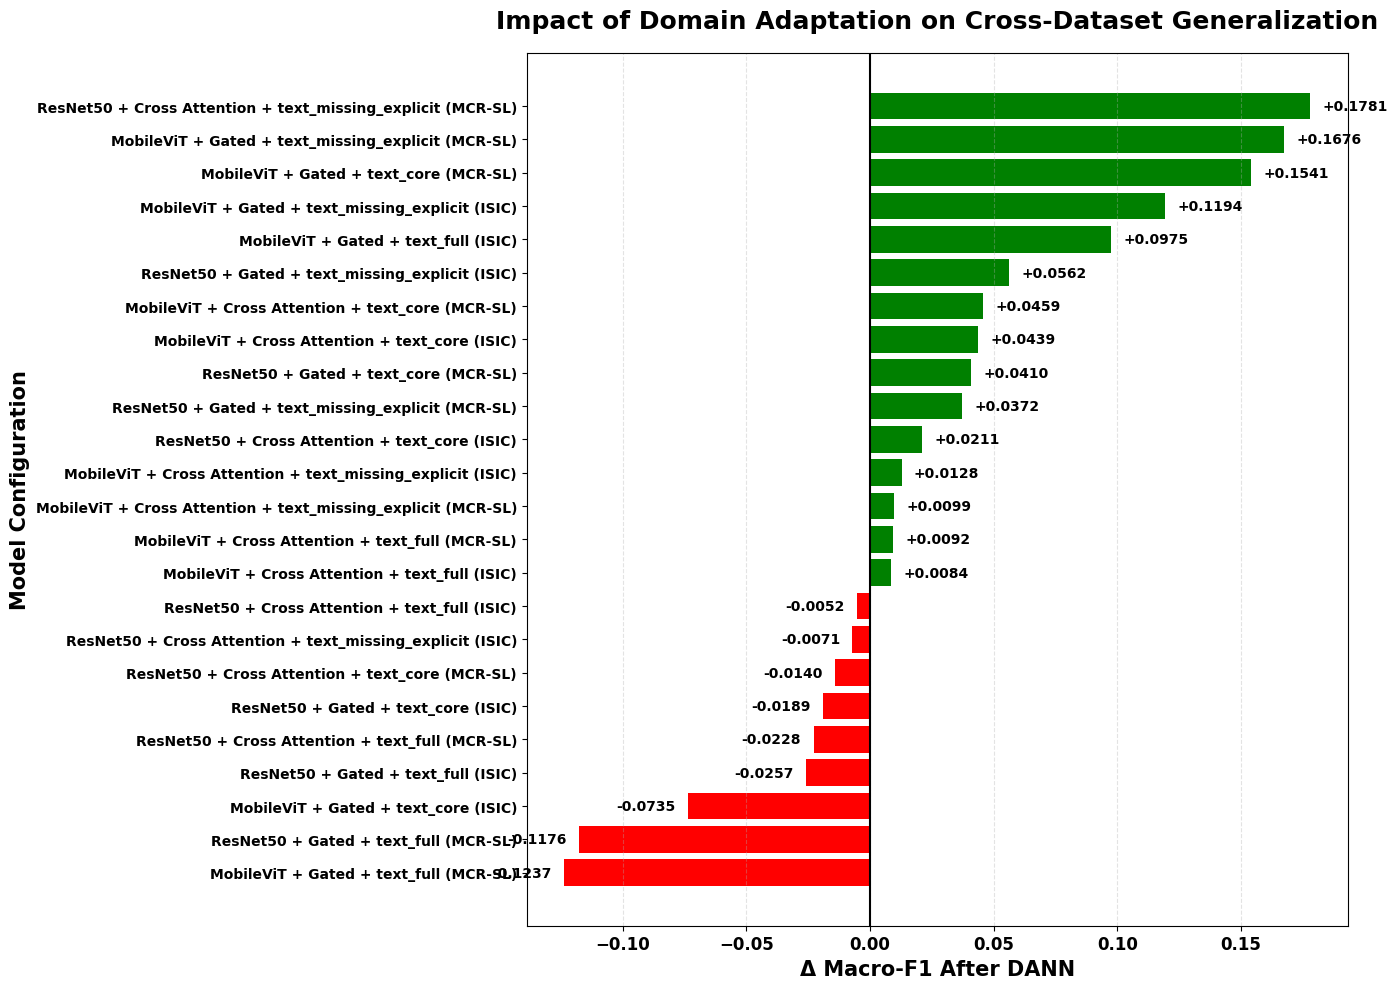

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Data: FINAL DANN - BEFORE DANN
# Main presentation metric: Delta Macro-F1
# ---------------------------------------------------------

data = [
    # ResNet50 + Gated
    ["ResNet50", "Gated", "ISIC", "text_full", -0.0257],
    ["ResNet50", "Gated", "ISIC", "text_core", -0.0189],
    ["ResNet50", "Gated", "ISIC", "text_missing_explicit", +0.0562],
    ["ResNet50", "Gated", "MCR-SL", "text_full", -0.1176],
    ["ResNet50", "Gated", "MCR-SL", "text_core", +0.0410],
    ["ResNet50", "Gated", "MCR-SL", "text_missing_explicit", +0.0372],

    # ResNet50 + Cross Attention
    ["ResNet50", "Cross Attention", "ISIC", "text_full", -0.0052],
    ["ResNet50", "Cross Attention", "ISIC", "text_core", +0.0211],
    ["ResNet50", "Cross Attention", "ISIC", "text_missing_explicit", -0.0071],
    ["ResNet50", "Cross Attention", "MCR-SL", "text_full", -0.0228],
    ["ResNet50", "Cross Attention", "MCR-SL", "text_core", -0.0140],
    ["ResNet50", "Cross Attention", "MCR-SL", "text_missing_explicit", +0.1781],

    # MobileViT + Cross Attention
    ["MobileViT", "Cross Attention", "ISIC", "text_full", +0.0084],
    ["MobileViT", "Cross Attention", "ISIC", "text_core", +0.0439],
    ["MobileViT", "Cross Attention", "ISIC", "text_missing_explicit", +0.0128],
    ["MobileViT", "Cross Attention", "MCR-SL", "text_full", +0.0092],
    ["MobileViT", "Cross Attention", "MCR-SL", "text_core", +0.0459],
    ["MobileViT", "Cross Attention", "MCR-SL", "text_missing_explicit", +0.0099],

    # MobileViT + Gated
    ["MobileViT", "Gated", "ISIC", "text_full", +0.0975],
    ["MobileViT", "Gated", "ISIC", "text_core", -0.0735],
    ["MobileViT", "Gated", "ISIC", "text_missing_explicit", +0.1194],
    ["MobileViT", "Gated", "MCR-SL", "text_full", -0.1237],
    ["MobileViT", "Gated", "MCR-SL", "text_core", +0.1541],
    ["MobileViT", "Gated", "MCR-SL", "text_missing_explicit", +0.1676],
]

df = pd.DataFrame(
    data,
    columns=["Backbone", "Fusion", "Dataset", "Text Model", "Delta Macro-F1"]
)

# Create readable configuration label
df["Configuration"] = (
    df["Backbone"] + " + " +
    df["Fusion"] + " + " +
    df["Text Model"] + " (" +
    df["Dataset"] + ")"
)

# Sort by delta performance
df = df.sort_values("Delta Macro-F1", ascending=True)

# Color strategy
colors = df["Delta Macro-F1"].apply(
    lambda x: "green" if x > 0 else "red"
)

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

plt.figure(figsize=(14, 10))

bars = plt.barh(
    df["Configuration"],
    df["Delta Macro-F1"],
    color=colors
)

# Zero reference line
plt.axvline(
    0,
    color="black",
    linewidth=1.5
)

# Title and labels
plt.title(
    "Impact of Domain Adaptation on Cross-Dataset Generalization",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Δ Macro-F1 After DANN",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "Model Configuration",
    fontsize=15,
    fontweight="bold"
)

# Bold tick labels
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")

# Add value labels
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width >= 0:
        x_position = width + 0.005
        ha = "left"
    else:
        x_position = width - 0.005
        ha = "right"

    plt.text(
        x_position,
        y,
        f"{width:+.4f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold"
    )

# Add grid for readability
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "delta_macro_f1_dann.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

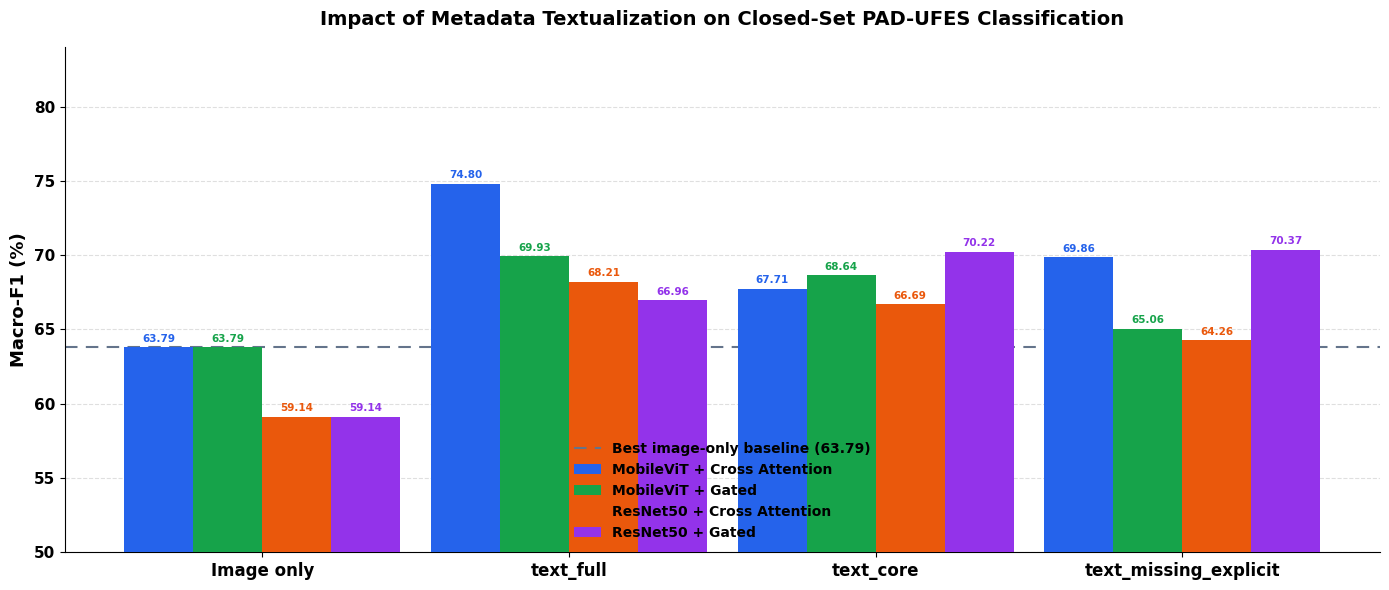

Saved.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
labels = ['Image only', 'text_full', 'text_core', 'text_missing_explicit']

models = {
    'MobileViT + Cross Attention': {'color': '#2563eb', 'data': [63.79, 74.80, 67.71, 69.86]},
    'MobileViT + Gated':           {'color': '#16a34a', 'data': [63.79, 69.93, 68.64, 65.06]},
    'ResNet50 + Cross Attention':  {'color': '#ea580c', 'data': [59.14, 68.21, 66.69, 64.26]},
    'ResNet50 + Gated':            {'color': '#9333ea', 'data': [59.14, 66.96, 70.22, 70.37]},
}

best_image_only = 63.79

# ── Layout ────────────────────────────────────────────────────────────────────
n_groups = len(labels)
n_models = len(models)
bar_width = 0.18
group_gap = 0.08
x = np.arange(n_groups) * (n_models * bar_width + group_gap)

fig, ax = plt.subplots(figsize=(14, 6))

# ── Bars ──────────────────────────────────────────────────────────────────────
for i, (name, cfg) in enumerate(models.items()):
    offsets = x + i * bar_width - (n_models - 1) * bar_width / 2
    bars = ax.bar(
        offsets, cfg['data'],
        width=bar_width,
        color=cfg['color'],
        label=name,
        zorder=3,
    )
    # Bold value labels on top of each bar
    for bar, val in zip(bars, cfg['data']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.25,
            f'{val:.2f}',
            ha='center', va='bottom',
            fontsize=7.5, fontweight='bold',
            color=cfg['color'],
        )

# ── Dashed baseline ───────────────────────────────────────────────────────────
ax.axhline(
    best_image_only,
    color='#64748b', linewidth=1.5,
    linestyle=(0, (6, 4)),
    label=f'Best image-only baseline ({best_image_only})',
    zorder=2,
)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_ylim(50, 84)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Macro-F1 (%)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

ax.set_title(
    'Impact of Metadata Textualization on Closed-Set PAD-UFES Classification',
    fontsize=14, fontweight='bold', pad=16,
)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    fontsize=10,
    frameon=False,
    loc='lower center',
    prop={'weight': 'bold'},
)

plt.tight_layout()
plt.savefig('metadata_textualization_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

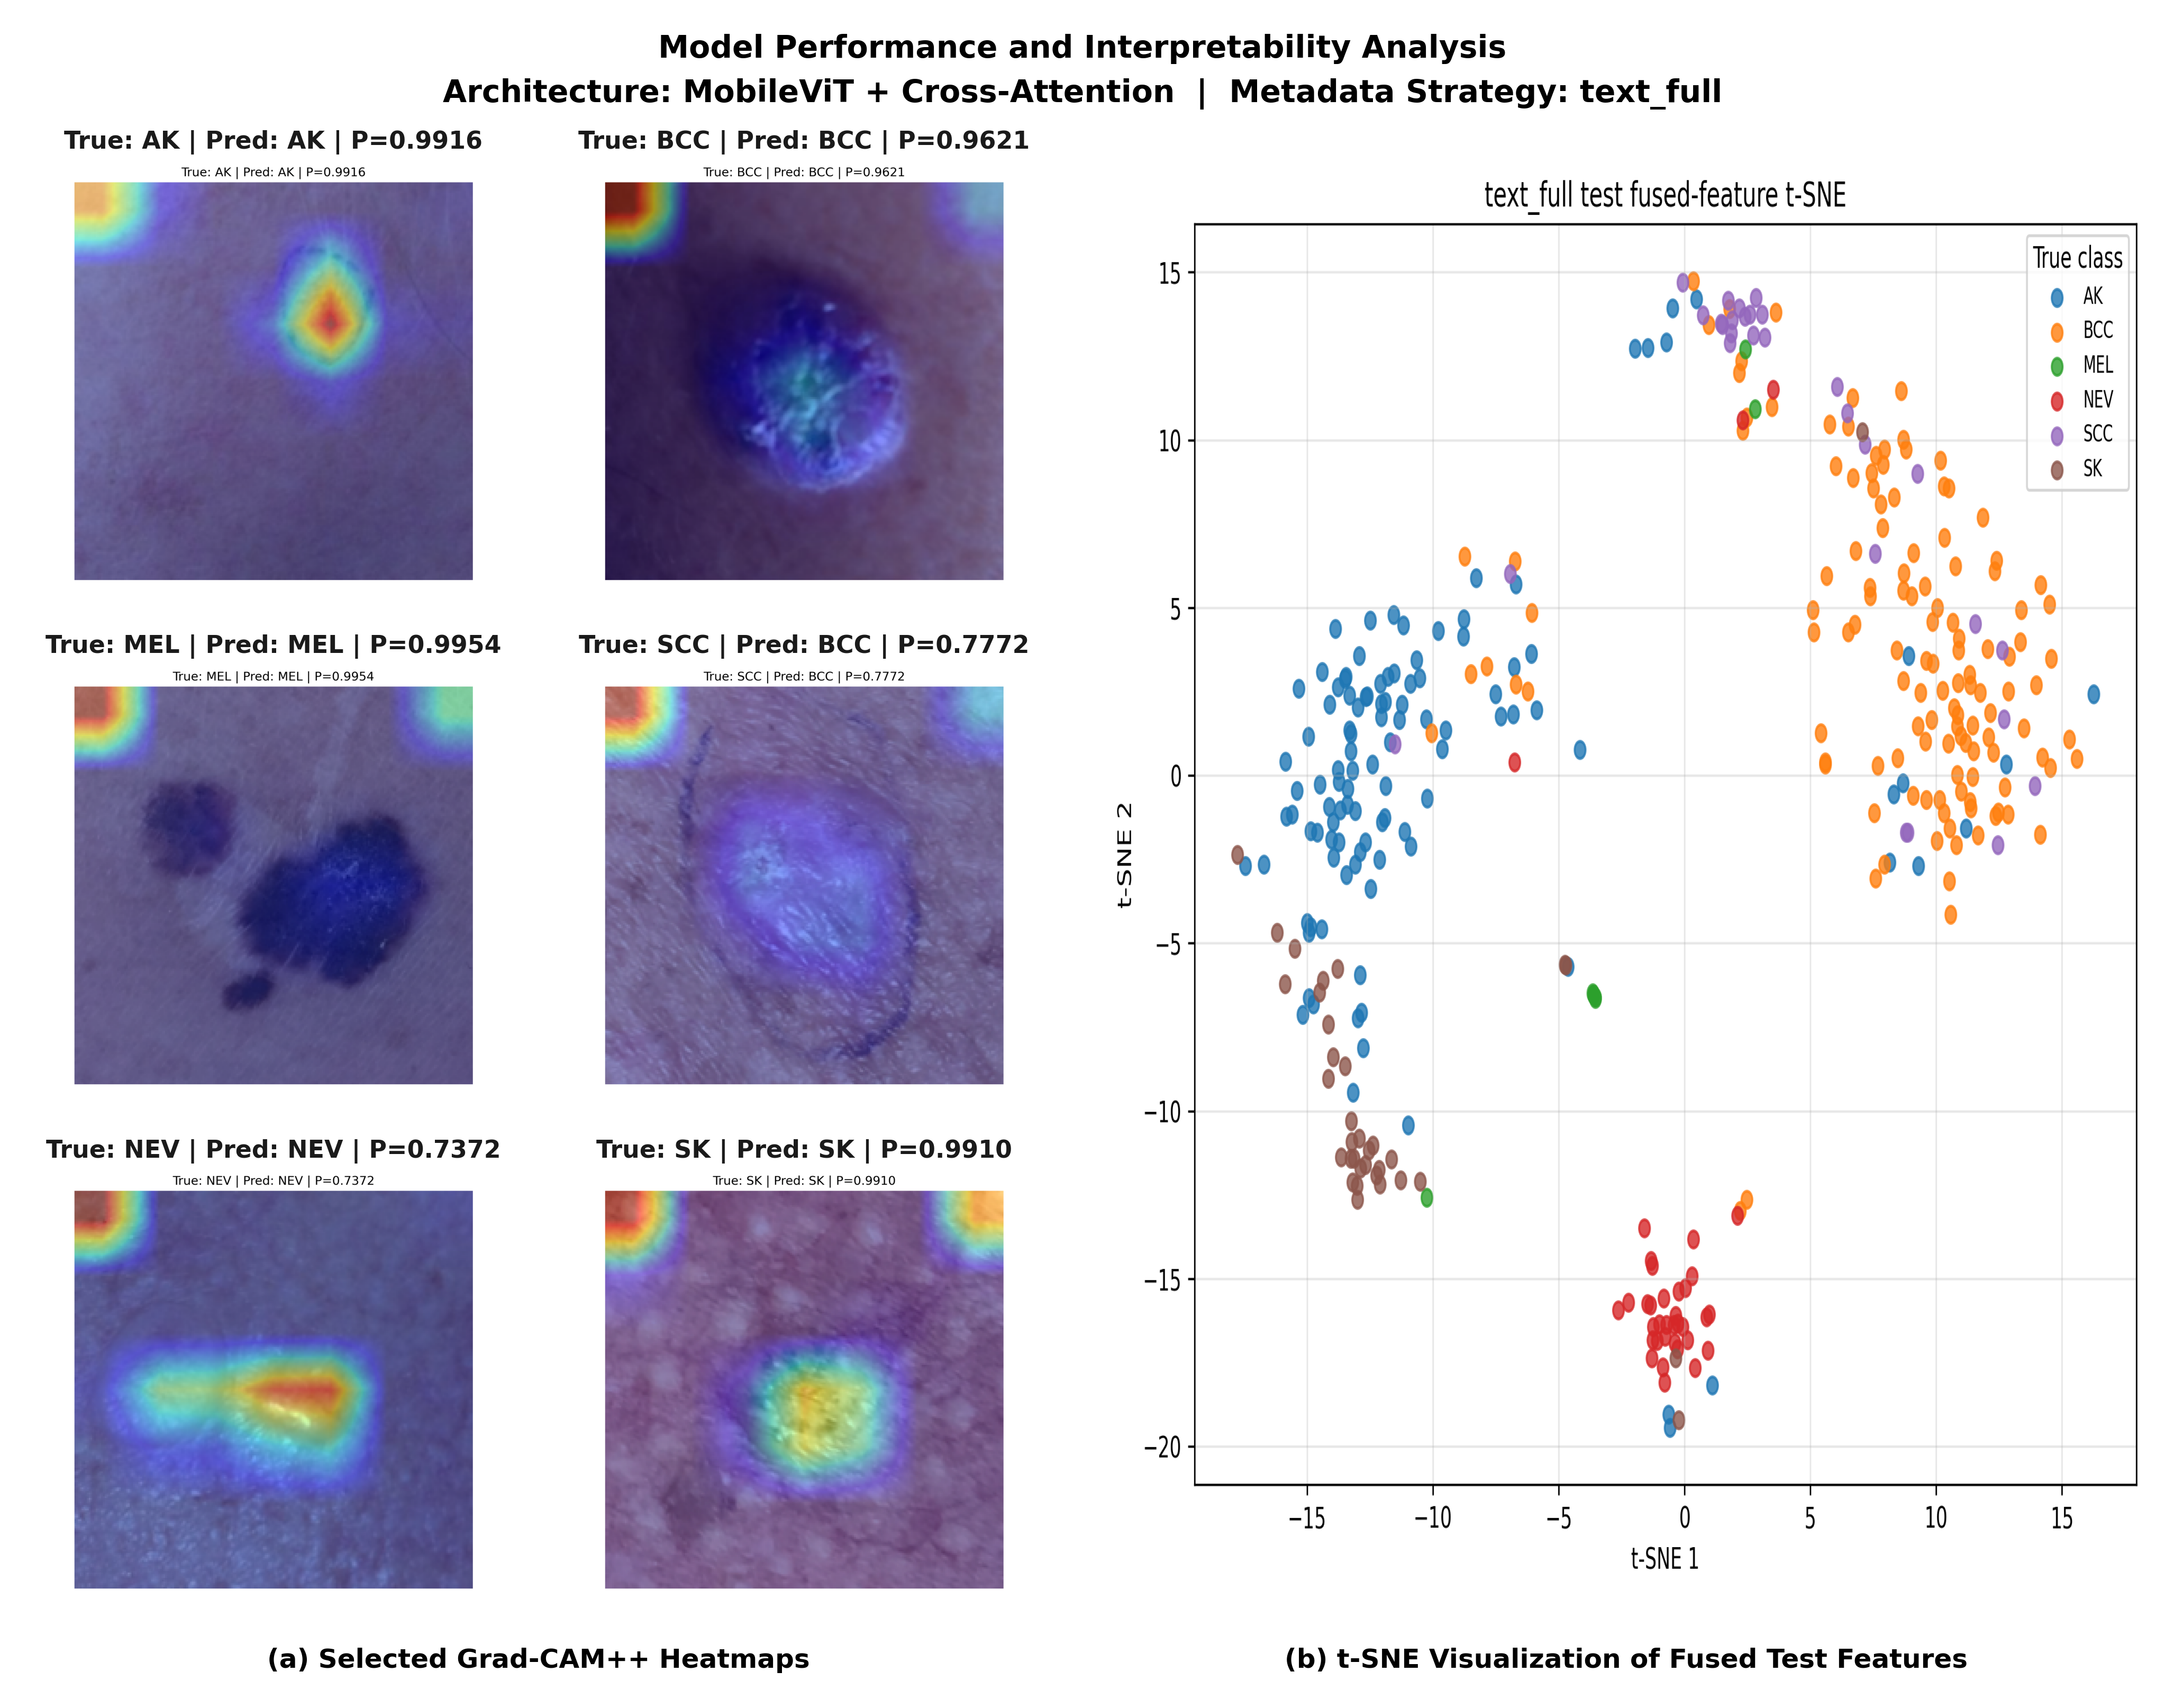

Saved to: D:\Deep Learning\output\text_full\combined_performance_analysis.png


In [16]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

def create_combined_figure():
    gradcam_dir = r"D:\Deep Learning\output\text_full\gradcampp_mobileVitCrossAttention"
    tsne_path   = r"D:\Deep Learning\output\text_full\test_tsne_true_labels.png"
    output_path = r"D:\Deep Learning\output\text_full\combined_performance_analysis.png"

    gradcam_configs = [
        ("gradcampp_00_true_AK_pred_AK.png",  "True: AK | Pred: AK | P=0.9916"),
        ("gradcampp_01_true_BCC_pred_BCC.png", "True: BCC | Pred: BCC | P=0.9621"),
        ("gradcampp_02_true_MEL_pred_MEL.png", "True: MEL | Pred: MEL | P=0.9954"),
        ("gradcampp_04_true_SCC_pred_BCC.png", "True: SCC | Pred: BCC | P=0.7772"),
        ("gradcampp_03_true_NEV_pred_NEV.png", "True: NEV | Pred: NEV | P=0.7372"),
        ("gradcampp_05_true_SK_pred_SK.png",   "True: SK | Pred: SK | P=0.9910"),
    ]

    fig = plt.figure(figsize=(14, 11), dpi=300, facecolor='white')

    # 3 rows: title strip | panels | caption strip
    # Increase height_ratio of title row to prevent overlap
    outer_gs = gridspec.GridSpec(
        3, 2,
        height_ratios=[1.4, 18, 0.8],   # <-- taller title row
        width_ratios=[1, 1],
        hspace=0.06,
        wspace=0.04,
        left=0.02, right=0.98,
        top=0.98, bottom=0.02,
    )

    # ── Main title spanning both columns (row 0) ──────────────────────────────
    ax_title = fig.add_subplot(outer_gs[0, :])
    ax_title.axis('off')
    ax_title.text(
        0.5, 0.5,
        "Model Performance and Interpretability Analysis\n"
        "Architecture: MobileViT + Cross-Attention  |  Metadata Strategy: text_full",
        ha='center', va='center',
        fontsize=14, fontweight='bold',
        linespacing=1.6,
        transform=ax_title.transAxes,
    )

    # ── Left: 3×2 Grad-CAM grid (row 1, col 0) ───────────────────────────────
    gradcam_gs = gridspec.GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec=outer_gs[1, 0],
        wspace=0.03,
        hspace=0.18,    # <-- slightly more vertical room for the larger titles
    )

    for idx, (filename, title_text) in enumerate(gradcam_configs):
        ax = fig.add_subplot(gradcam_gs[idx])
        full_path = os.path.join(gradcam_dir, filename)
        if not os.path.exists(full_path):
            full_path = full_path.replace(".png", ".jpg")
        try:
            ax.imshow(Image.open(full_path))
            ax.set_title(
                title_text,
                fontsize=11,           # <-- increased from 9
                pad=5,
                fontweight='bold',     # <-- bold
                color='#1a1a1a',
            )
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"Missing:\n{filename}",
                    ha='center', va='center', color='red', fontsize=9)
            ax.set_facecolor('#f8d7da')
        ax.axis('off')

    # ── Right: t-SNE fills full column height (row 1, col 1) ─────────────────
    ax_tsne = fig.add_subplot(outer_gs[1, 1])
    tsne_used = tsne_path
    if not os.path.exists(tsne_used):
        tsne_used = tsne_used.replace(".png", ".jpg")
    try:
        ax_tsne.imshow(Image.open(tsne_used), aspect='auto')
    except FileNotFoundError:
        ax_tsne.text(0.5, 0.5, f"t-SNE not found:\n{tsne_path}",
                     ha='center', va='center', color='red', fontsize=11)
        ax_tsne.set_facecolor('#f8d7da')
    ax_tsne.axis('off')

    # ── Captions (row 2) ──────────────────────────────────────────────────────
    ax_cap_left = fig.add_subplot(outer_gs[2, 0])
    ax_cap_left.axis('off')
    ax_cap_left.text(0.5, 0.5, "(a) Selected Grad-CAM++ Heatmaps",
                     ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     transform=ax_cap_left.transAxes)

    ax_cap_right = fig.add_subplot(outer_gs[2, 1])
    ax_cap_right.axis('off')
    ax_cap_right.text(0.5, 0.5, "(b) t-SNE Visualization of Fused Test Features",
                      ha='center', va='center',
                      fontsize=12, fontweight='bold',
                      transform=ax_cap_right.transAxes)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight', dpi=650)
    plt.show()
    print(f"Saved to: {output_path}")

if __name__ == "__main__":
    create_combined_figure()